# Análise Exploratória de Dados

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.filters.hp_filter import hpfilter
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss

ROOT_PATH = os.path.dirname(os.getcwd())
DATA_FOLDER_PATH = os.path.join(ROOT_PATH, 'data', 'processed')

COVID_START = pd.Timestamp('2020-01-01')
COVID_END = pd.Timestamp('2021-12-31')

sns.set_palette('colorblind')

## Importação de Dados

In [2]:
df = pd.read_parquet(os.path.join(DATA_FOLDER_PATH, 'train_ptbr.parquet'))

df = df.set_index('date')
df['is_covid_19'] = (df.index >= COVID_START) & (df.index <= COVID_END)

df.head()

,access_route,state,origin_country,month,year,arrival_count,month_num,year_month,state_region,country_cultural_subdivision,is_covid_19
date,,,,,,,,,,,
1989-01-31,Aérea,Amazonas,África do Sul,Janeiro,1989,9.0,01,1989-01-31,Região Norte,África Subsaariana,False
1989-01-31,Aérea,Amazonas,Angola,Janeiro,1989,0.0,01,1989-01-31,Região Norte,África Subsaariana,False
1989-01-31,Aérea,Amazonas,Nigéria,Janeiro,1989,0.0,01,1989-01-31,Região Norte,África Subsaariana,False
1989-01-31,Aérea,Amazonas,Outros países,Janeiro,1989,0.0,01,1989-01-31,Região Norte,Outros,False
1989-01-31,Aérea,Amazonas,Costa Rica,Janeiro,1989,6.0,01,1989-01-31,Região Norte,LATAM,False


## Análise de Variáveis Categóricas

### Via de Acesso

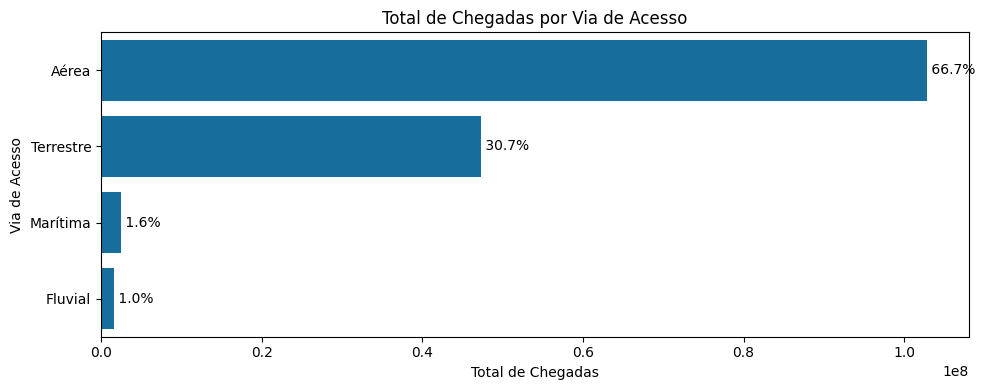

In [3]:
top_access_route = pd.DataFrame(
    df.groupby('access_route')['arrival_count'].sum().nlargest(20)
)
top_access_route['percentage'] = (
    top_access_route['arrival_count'] / top_access_route['arrival_count'].sum()
) * 100

plt.figure(figsize=(10, 4))

sns.barplot(x=top_access_route['arrival_count'], y=top_access_route.index)
plt.title('Total de Chegadas por Via de Acesso')
plt.xlabel('Total de Chegadas')
plt.ylabel('Via de Acesso')

ax = plt.gca()
for i, (count, pct) in enumerate(
    zip(top_access_route['arrival_count'], top_access_route['percentage'])
):
    ax.text(count, i, f' {pct:.1f}%', va='center', ha='left')

plt.tight_layout()

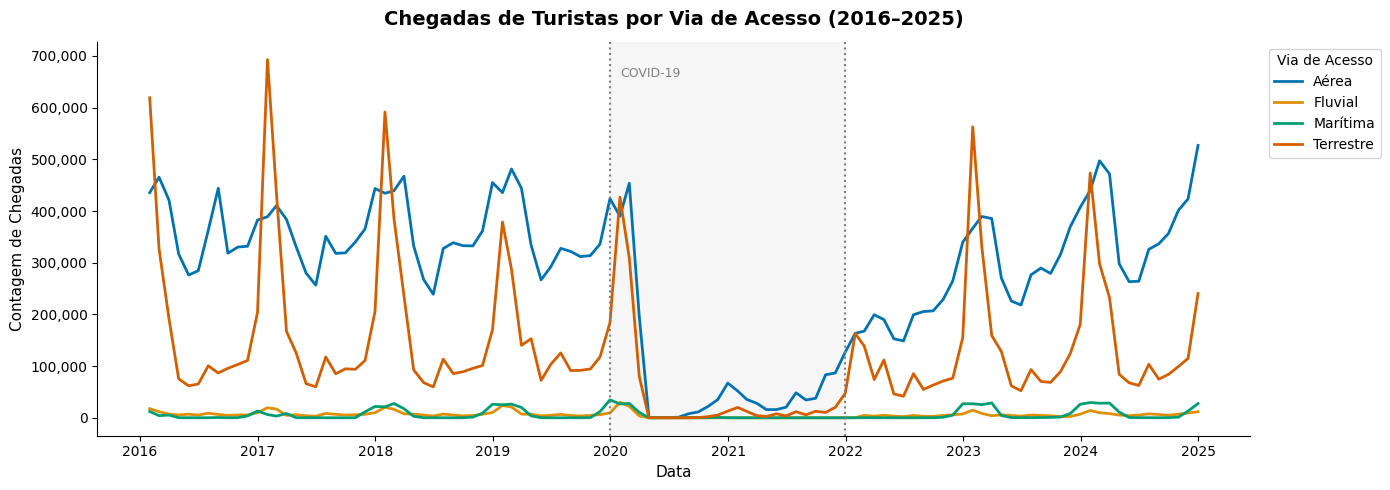

In [4]:
route_time = (
    df[df.index.year >= 2016]
    .groupby(['year_month', 'access_route'], as_index=False)['arrival_count']
    .sum()
)

fig, ax = plt.subplots(figsize=(14, 5))

sns.lineplot(
    data=route_time,
    x='year_month',
    y='arrival_count',
    hue='access_route',
    linewidth=2,
    ax=ax,
)

ax.axvline(COVID_START, color='gray', linestyle=':', linewidth=1.5, label='_nolegend_')
ax.axvline(COVID_END, color='gray', linestyle=':', linewidth=1.5, label='_nolegend_')
ax.axvspan(COVID_START, COVID_END, alpha=0.07, color='gray')

y_max = route_time['arrival_count'].max()
ax.text(
    COVID_START + pd.Timedelta(days=30),
    y_max * 0.95,
    'COVID-19',
    fontsize=9,
    color='gray',
)

ax.set_title(
    'Chegadas de Turistas por Via de Acesso (2016–2025)',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Data', fontsize=11)
ax.set_ylabel('Contagem de Chegadas', fontsize=11)
ax.legend(
    title='Via de Acesso', bbox_to_anchor=(1.01, 1), loc='upper left', frameon=True
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()

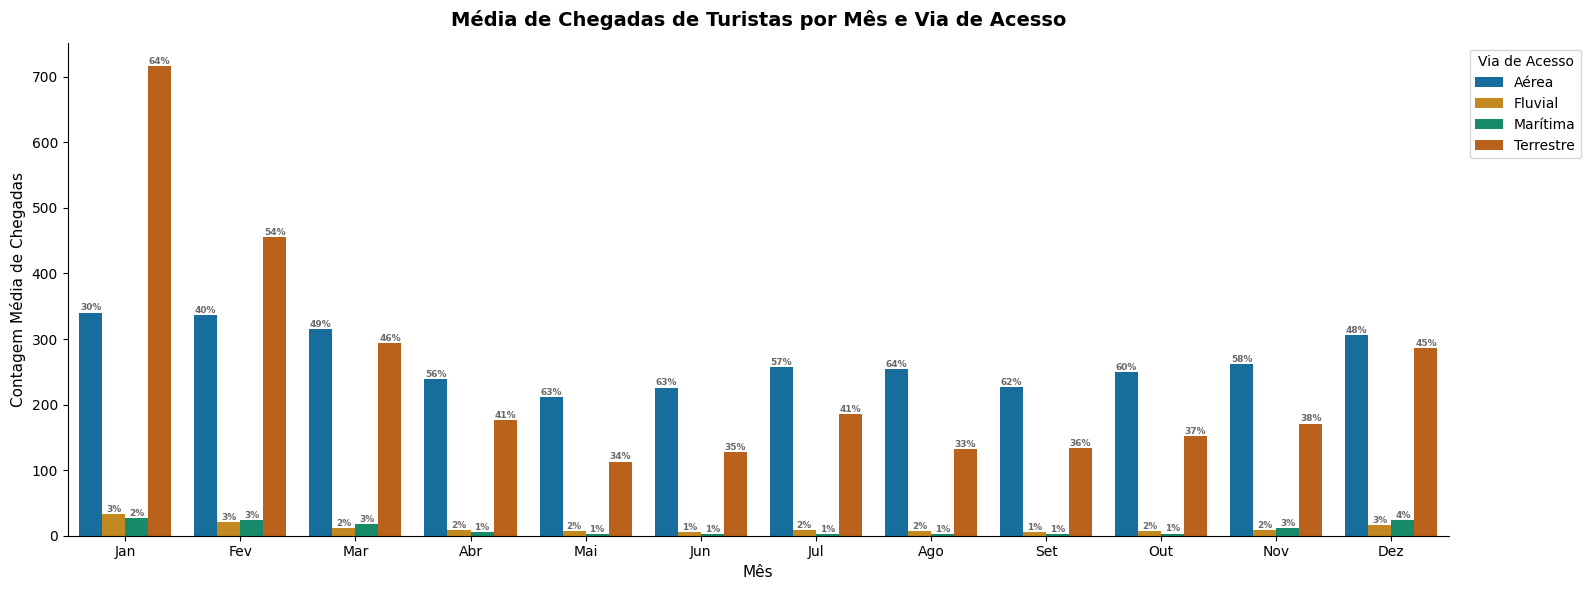

In [5]:
month_route = (
    df.groupby(['month_num', 'access_route'])['arrival_count'].mean().reset_index()
)

month_totals = month_route.groupby('month_num')['arrival_count'].sum()
month_route['pct'] = month_route.apply(
    lambda r: r['arrival_count'] / month_totals[r['month_num']] * 100, axis=1
)

# Abreviações de meses em português
month_labels = [
    'Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun',
    'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez',
]
month_route['month_label'] = (
    month_route['month_num'].astype(int).apply(lambda m: month_labels[m - 1])
)

fig, ax = plt.subplots(figsize=(16, 6))

sns.barplot(
    data=month_route,
    x='month_label',
    y='arrival_count',
    hue='access_route',
    order=month_labels,
    ax=ax,
)

# Re-anota com valores de pct reais por grupo de barras
ax.cla()
bar_plot = sns.barplot(
    data=month_route,
    x='month_label',
    y='arrival_count',
    hue='access_route',
    order=month_labels,
    ax=ax,
)

routes = month_route['access_route'].unique()
for month_idx, month in enumerate(month_labels):
    month_data = month_route[month_route['month_label'] == month].set_index(
        'access_route'
    )
    n_routes = len(routes)
    total_width = 0.8
    bar_width = total_width / n_routes
    for route_idx, route in enumerate(routes):
        if route not in month_data.index:
            continue
        row = month_data.loc[route]
        x = month_idx - total_width / 2 + bar_width * route_idx + bar_width / 2
        ax.text(
            x,
            row['arrival_count'] + 0.3,
            f'{row["pct"]:.0f}%',
            ha='center',
            va='bottom',
            fontsize=6.5,
            color='dimgray',
            fontweight='bold',
        )

ax.set_title(
    'Média de Chegadas de Turistas por Mês e Via de Acesso',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Mês', fontsize=11)
ax.set_ylabel('Contagem Média de Chegadas', fontsize=11)
ax.legend(
    title='Via de Acesso', bbox_to_anchor=(1.01, 1), loc='upper left', frameon=True
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()

### Estado e Região de Destino

#### Estado de Destino

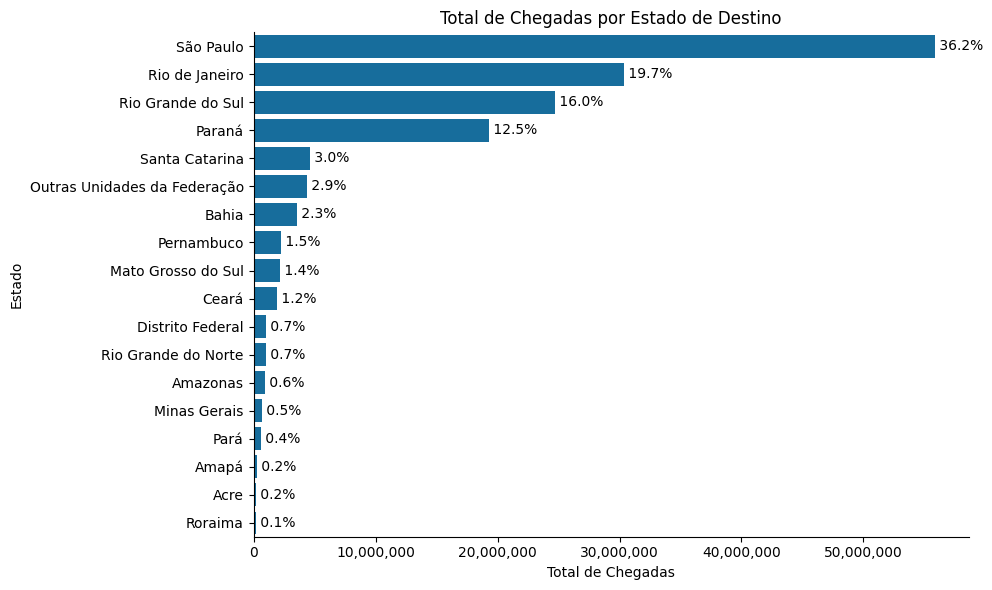

In [6]:
top_states = pd.DataFrame(df.groupby('state')['arrival_count'].sum().nlargest(30))
top_states['percentage'] = (
    top_states['arrival_count'] / top_states['arrival_count'].sum()
) * 100

plt.figure(figsize=(10, 6))

sns.barplot(x=top_states['arrival_count'], y=top_states.index)
plt.title('Total de Chegadas por Estado de Destino')
plt.xlabel('Total de Chegadas')
plt.ylabel('Estado')

ax = plt.gca()
for i, (count, pct) in enumerate(
    zip(top_states['arrival_count'], top_states['percentage'])
):
    ax.text(count, i, f' {pct:.1f}%', va='center', ha='left')

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()

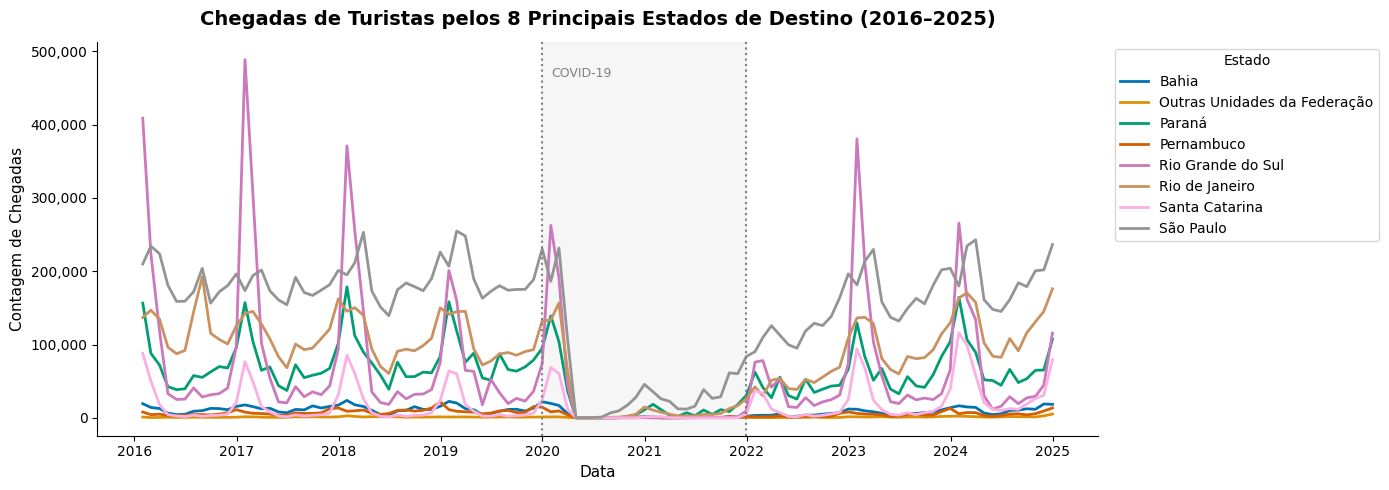

In [7]:
TOP_N = 8
top_state_names = (
    df.groupby('state')['arrival_count'].sum().nlargest(TOP_N).index.tolist()
)

state_time = (
    df[df['state'].isin(top_state_names) & (df.index.year >= 2016)]
    .groupby(['year_month', 'state'], as_index=False)['arrival_count']
    .sum()
)

fig, ax = plt.subplots(figsize=(14, 5))

sns.lineplot(
    data=state_time,
    x='year_month',
    y='arrival_count',
    hue='state',
    linewidth=2,
    ax=ax,
)

ax.axvline(COVID_START, color='gray', linestyle=':', linewidth=1.5, label='_nolegend_')
ax.axvline(COVID_END, color='gray', linestyle=':', linewidth=1.5, label='_nolegend_')
ax.axvspan(COVID_START, COVID_END, alpha=0.07, color='gray')

y_max = state_time['arrival_count'].max()
ax.text(
    COVID_START + pd.Timedelta(days=30),
    y_max * 0.95,
    'COVID-19',
    fontsize=9,
    color='gray',
)

ax.set_title(
    f'Chegadas de Turistas pelos {TOP_N} Principais Estados de Destino (2016–2025)',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Data', fontsize=11)
ax.set_ylabel('Contagem de Chegadas', fontsize=11)
ax.legend(title='Estado', bbox_to_anchor=(1.01, 1), loc='upper left', frameon=True)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()

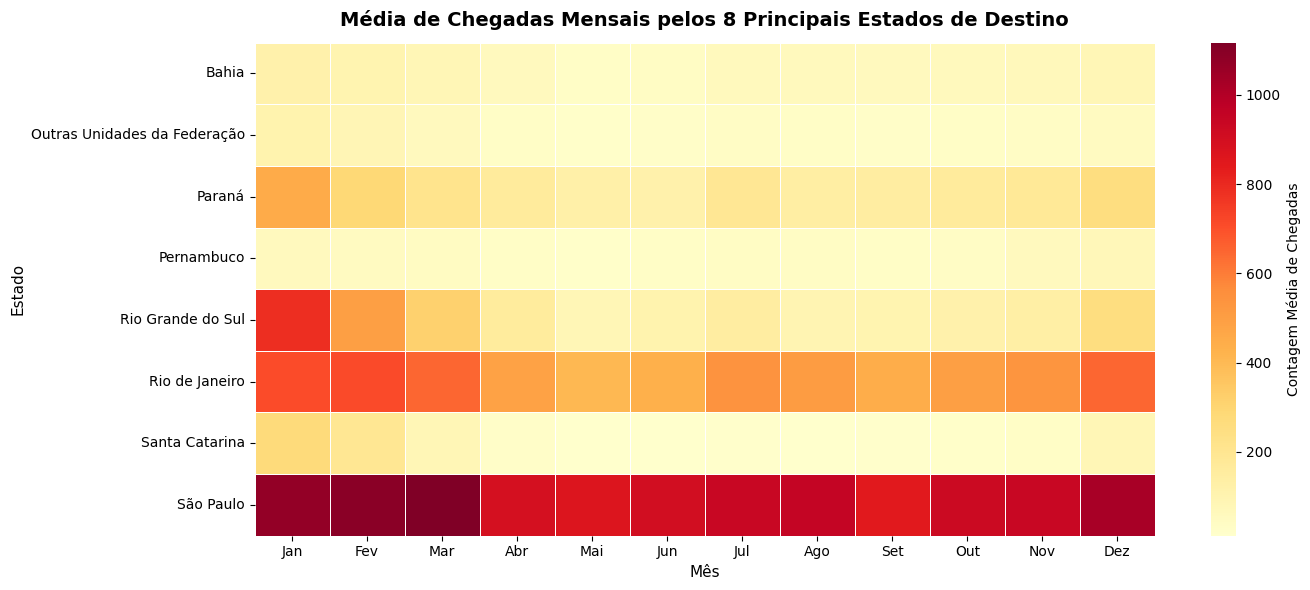

In [8]:
month_labels = [
    'Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun',
    'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez',
]

state_month = (
    df[df['state'].isin(top_state_names)]
    .groupby(['state', 'month_num'])['arrival_count']
    .mean()
    .unstack('month_num')
)
state_month.columns = month_labels

fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(
    state_month,
    fmt='.0f',
    linewidths=0.4,
    cmap='YlOrRd',
    ax=ax,
    cbar_kws={'label': 'Contagem Média de Chegadas'},
)

ax.set_title(
    f'Média de Chegadas Mensais pelos {TOP_N} Principais Estados de Destino',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Mês', fontsize=11)
ax.set_ylabel('Estado', fontsize=11)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()

#### Região de Destino

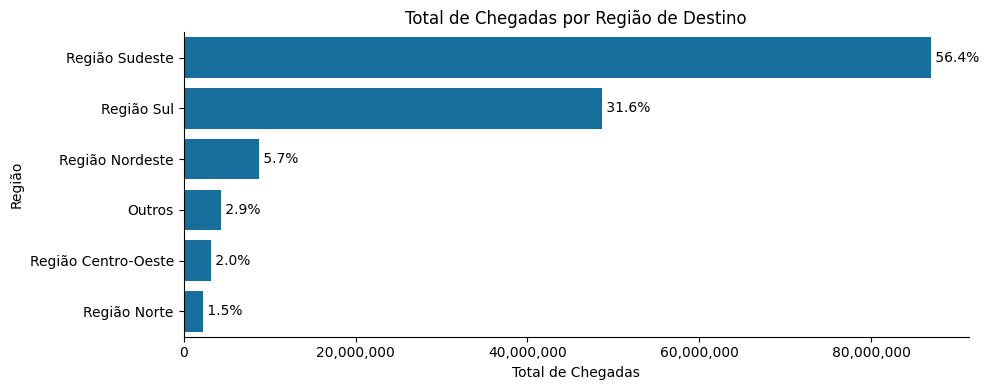

In [9]:
region_totals = pd.DataFrame(
    df.groupby('state_region')['arrival_count'].sum().sort_values(ascending=False)
)
region_totals['percentage'] = (
    region_totals['arrival_count'] / region_totals['arrival_count'].sum()
) * 100

plt.figure(figsize=(10, 4))

sns.barplot(x=region_totals['arrival_count'], y=region_totals.index)
plt.title('Total de Chegadas por Região de Destino')
plt.xlabel('Total de Chegadas')
plt.ylabel('Região')

ax = plt.gca()
for i, (count, pct) in enumerate(
    zip(region_totals['arrival_count'], region_totals['percentage'])
):
    ax.text(count, i, f' {pct:.1f}%', va='center', ha='left')

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()

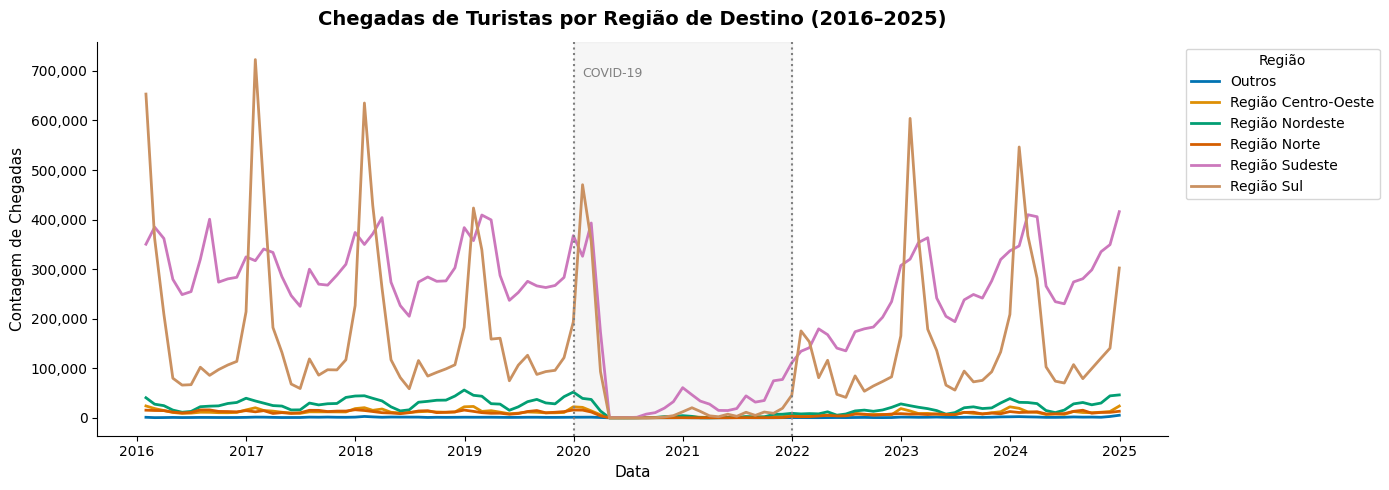

In [10]:
region_time = (
    df[df.index.year >= 2016]
    .groupby(['year_month', 'state_region'], as_index=False)['arrival_count']
    .sum()
)

fig, ax = plt.subplots(figsize=(14, 5))

sns.lineplot(
    data=region_time,
    x='year_month',
    y='arrival_count',
    hue='state_region',
    linewidth=2,
    ax=ax,
)

ax.axvline(COVID_START, color='gray', linestyle=':', linewidth=1.5, label='_nolegend_')
ax.axvline(COVID_END, color='gray', linestyle=':', linewidth=1.5, label='_nolegend_')
ax.axvspan(COVID_START, COVID_END, alpha=0.07, color='gray')

y_max = region_time['arrival_count'].max()
ax.text(
    COVID_START + pd.Timedelta(days=30),
    y_max * 0.95,
    'COVID-19',
    fontsize=9,
    color='gray',
)

ax.set_title(
    'Chegadas de Turistas por Região de Destino (2016–2025)',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Data', fontsize=11)
ax.set_ylabel('Contagem de Chegadas', fontsize=11)
ax.legend(title='Região', bbox_to_anchor=(1.01, 1), loc='upper left', frameon=True)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()

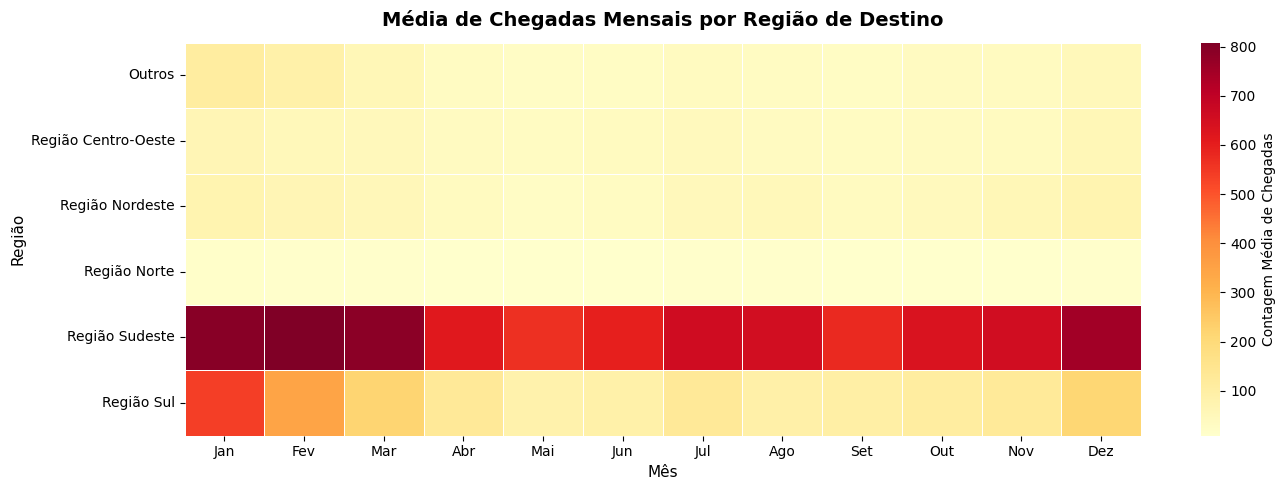

In [11]:
month_labels = [
    'Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun',
    'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez',
]

region_month = (
    df
    .groupby(['state_region', 'month_num'])['arrival_count']
    .mean()
    .unstack('month_num')
)
region_month.columns = month_labels

fig, ax = plt.subplots(figsize=(14, 5))

sns.heatmap(
    region_month,
    fmt='.0f',
    linewidths=0.4,
    cmap='YlOrRd',
    ax=ax,
    cbar_kws={'label': 'Contagem Média de Chegadas'},
)

ax.set_title(
    'Média de Chegadas Mensais por Região de Destino',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Mês', fontsize=11)
ax.set_ylabel('Região', fontsize=11)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()

### País de Origem / Subdivisão Cultural

#### País de Origem

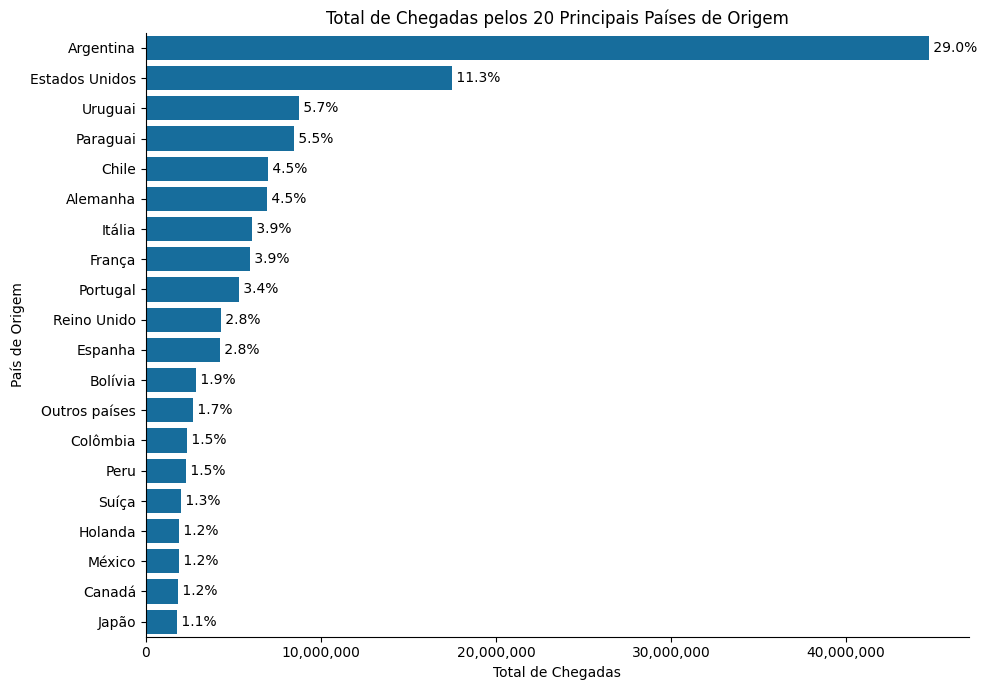

In [12]:
TOP_N_COUNTRIES = 20

top_countries = pd.DataFrame(
    df.groupby('origin_country')['arrival_count'].sum().nlargest(TOP_N_COUNTRIES)
)
top_countries['percentage'] = (
    top_countries['arrival_count']
    / df.groupby('origin_country')['arrival_count'].sum().sum()
) * 100

plt.figure(figsize=(10, 7))

sns.barplot(x=top_countries['arrival_count'], y=top_countries.index)
plt.title(f'Total de Chegadas pelos {TOP_N_COUNTRIES} Principais Países de Origem')
plt.xlabel('Total de Chegadas')
plt.ylabel('País de Origem')

ax = plt.gca()
for i, (count, pct) in enumerate(
    zip(top_countries['arrival_count'], top_countries['percentage'])
):
    ax.text(count, i, f' {pct:.1f}%', va='center', ha='left')

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()

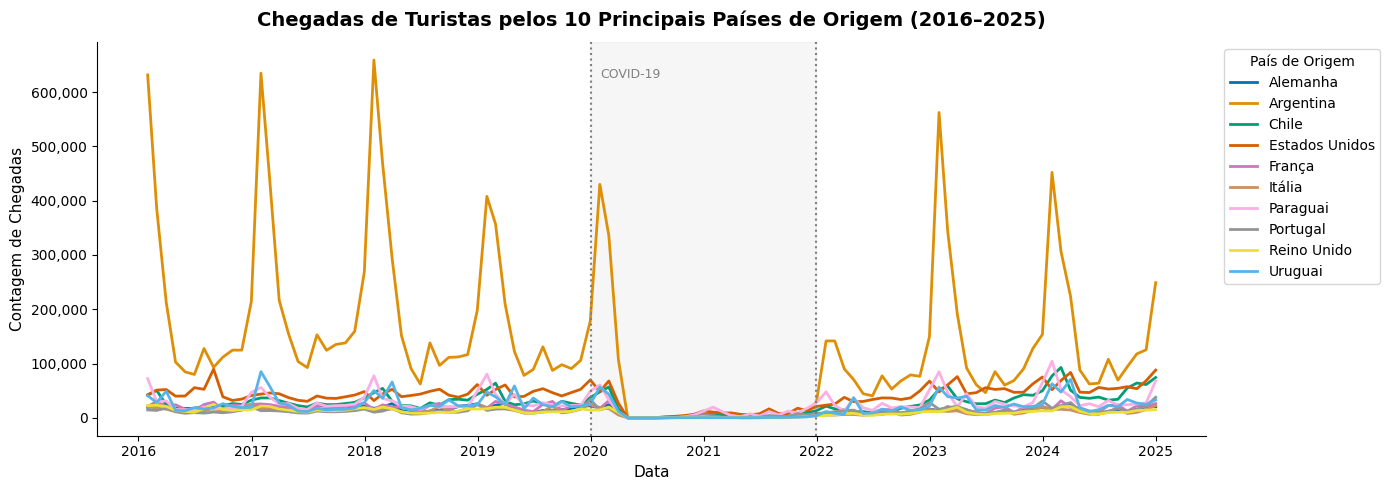

In [13]:
TOP_N_COUNTRIES = 10

top_country_names = (
    df
    .groupby('origin_country')['arrival_count']
    .sum()
    .nlargest(TOP_N_COUNTRIES)
    .index.tolist()
)

country_time = (
    df[df['origin_country'].isin(top_country_names) & (df.index.year >= 2016)]
    .groupby(['year_month', 'origin_country'], as_index=False)['arrival_count']
    .sum()
)

fig, ax = plt.subplots(figsize=(14, 5))

sns.lineplot(
    data=country_time,
    x='year_month',
    y='arrival_count',
    hue='origin_country',
    linewidth=2,
    ax=ax,
)

ax.axvline(COVID_START, color='gray', linestyle=':', linewidth=1.5, label='_nolegend_')
ax.axvline(COVID_END, color='gray', linestyle=':', linewidth=1.5, label='_nolegend_')
ax.axvspan(COVID_START, COVID_END, alpha=0.07, color='gray')

y_max = country_time['arrival_count'].max()
ax.text(
    COVID_START + pd.Timedelta(days=30),
    y_max * 0.95,
    'COVID-19',
    fontsize=9,
    color='gray',
)

ax.set_title(
    f'Chegadas de Turistas pelos {TOP_N_COUNTRIES} Principais Países de Origem (2016–2025)',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Data', fontsize=11)
ax.set_ylabel('Contagem de Chegadas', fontsize=11)
ax.legend(
    title='País de Origem', bbox_to_anchor=(1.01, 1), loc='upper left', frameon=True
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()

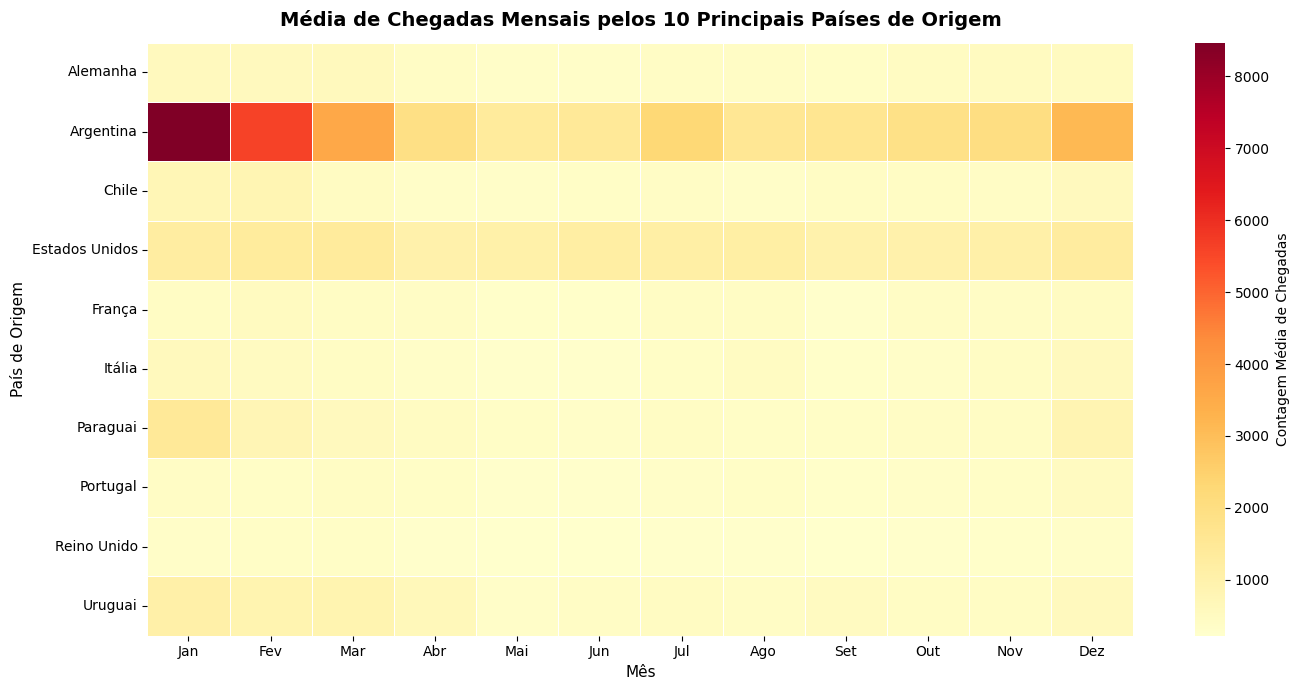

In [14]:
month_labels = [
    'Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun',
    'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez',
]

country_month = (
    df[df['origin_country'].isin(top_country_names)]
    .groupby(['origin_country', 'month_num'])['arrival_count']
    .mean()
    .unstack('month_num')
)
country_month.columns = month_labels

fig, ax = plt.subplots(figsize=(14, 7))

sns.heatmap(
    country_month,
    fmt='.0f',
    linewidths=0.4,
    cmap='YlOrRd',
    ax=ax,
    cbar_kws={'label': 'Contagem Média de Chegadas'},
)

ax.set_title(
    f'Média de Chegadas Mensais pelos {TOP_N_COUNTRIES} Principais Países de Origem',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Mês', fontsize=11)
ax.set_ylabel('País de Origem', fontsize=11)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()

#### Subdivisão Cultural

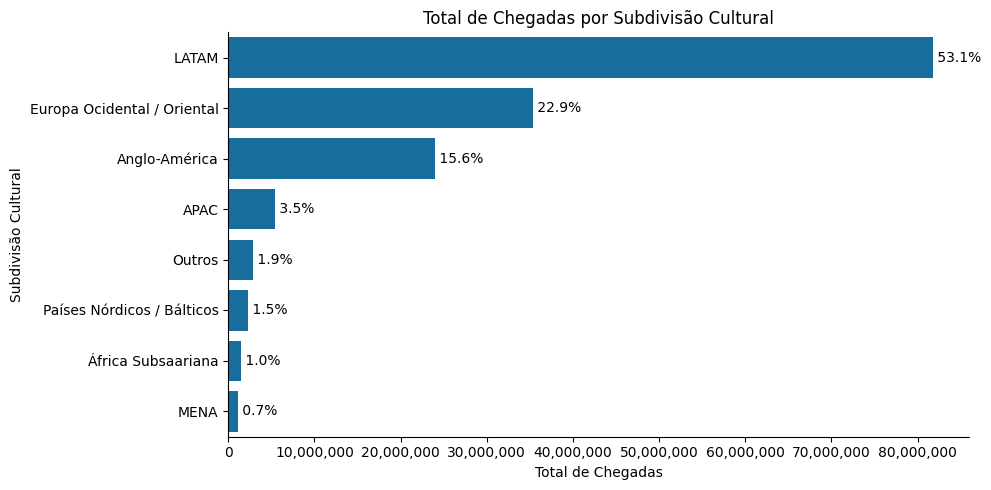

In [15]:
subdivision_totals = pd.DataFrame(
    df
    .groupby('country_cultural_subdivision')['arrival_count']
    .sum()
    .sort_values(ascending=False)
)
subdivision_totals['percentage'] = (
    subdivision_totals['arrival_count'] / subdivision_totals['arrival_count'].sum()
) * 100

plt.figure(figsize=(10, 5))

sns.barplot(x=subdivision_totals['arrival_count'], y=subdivision_totals.index)
plt.title('Total de Chegadas por Subdivisão Cultural')
plt.xlabel('Total de Chegadas')
plt.ylabel('Subdivisão Cultural')

ax = plt.gca()
for i, (count, pct) in enumerate(
    zip(subdivision_totals['arrival_count'], subdivision_totals['percentage'])
):
    ax.text(count, i, f' {pct:.1f}%', va='center', ha='left')

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()

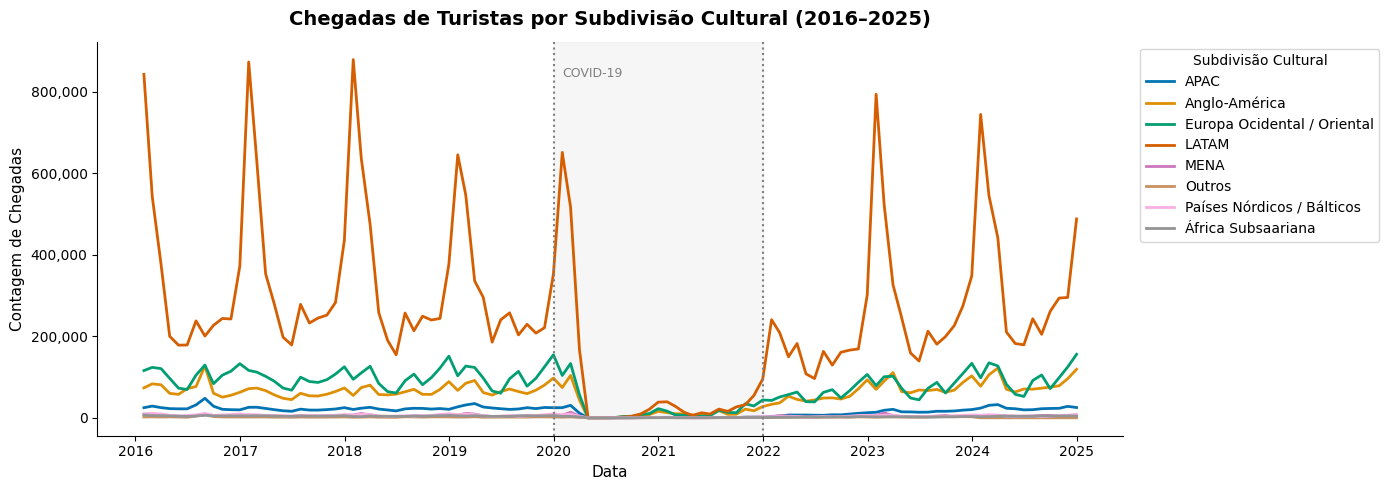

In [16]:
subdivision_time = (
    df[df.index.year >= 2016]
    .groupby(['year_month', 'country_cultural_subdivision'], as_index=False)[
        'arrival_count'
    ]
    .sum()
)

fig, ax = plt.subplots(figsize=(14, 5))

sns.lineplot(
    data=subdivision_time,
    x='year_month',
    y='arrival_count',
    hue='country_cultural_subdivision',
    linewidth=2,
    ax=ax,
)

ax.axvline(COVID_START, color='gray', linestyle=':', linewidth=1.5, label='_nolegend_')
ax.axvline(COVID_END, color='gray', linestyle=':', linewidth=1.5, label='_nolegend_')
ax.axvspan(COVID_START, COVID_END, alpha=0.07, color='gray')

y_max = subdivision_time['arrival_count'].max()
ax.text(
    COVID_START + pd.Timedelta(days=30),
    y_max * 0.95,
    'COVID-19',
    fontsize=9,
    color='gray',
)

ax.set_title(
    'Chegadas de Turistas por Subdivisão Cultural (2016–2025)',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Data', fontsize=11)
ax.set_ylabel('Contagem de Chegadas', fontsize=11)
ax.legend(
    title='Subdivisão Cultural',
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    frameon=True,
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()

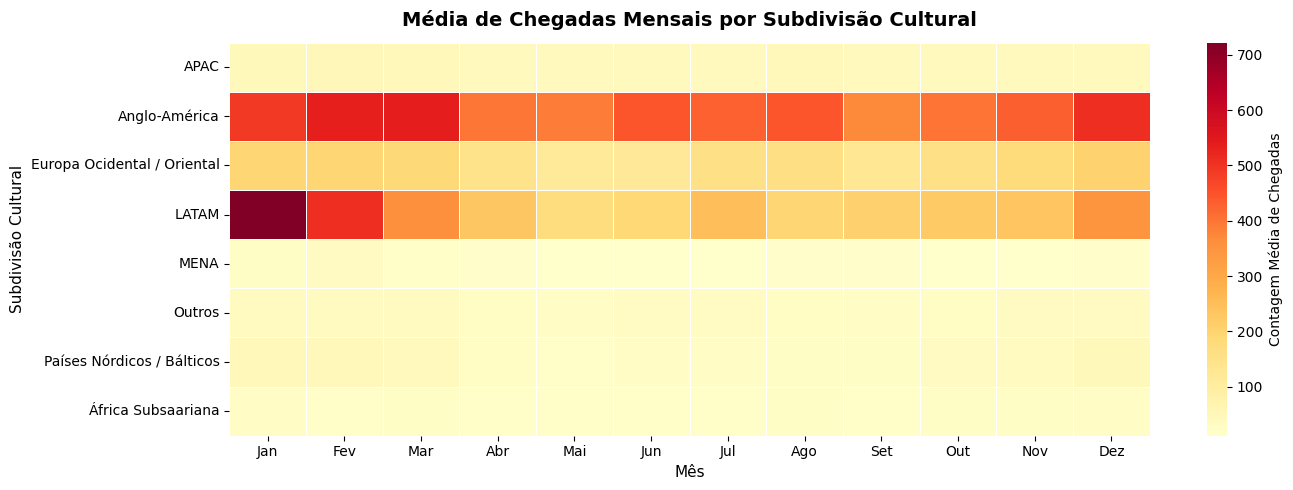

In [17]:
month_labels = [
    'Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun',
    'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez',
]

subdivision_month = (
    df
    .groupby(['country_cultural_subdivision', 'month_num'])['arrival_count']
    .mean()
    .unstack('month_num')
)
subdivision_month.columns = month_labels

fig, ax = plt.subplots(figsize=(14, 5))

sns.heatmap(
    subdivision_month,
    fmt='.0f',
    linewidths=0.4,
    cmap='YlOrRd',
    ax=ax,
    cbar_kws={'label': 'Contagem Média de Chegadas'},
)

ax.set_title(
    'Média de Chegadas Mensais por Subdivisão Cultural',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Mês', fontsize=11)
ax.set_ylabel('Subdivisão Cultural', fontsize=11)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()

## Análise de Séries Temporais

#### Visão Geral

In [18]:
monthly_df = df[['arrival_count']].resample('ME').sum()


def assign_period(date):
    """Classifica cada data em um período histórico."""
    if date < pd.Timestamp('2000-01-01'):
        return 'Histórico (< 2000)'
    elif date < COVID_START:
        return 'Pré-Pandemia (2000–2019)'
    elif date <= COVID_END:
        return 'Pandemia (2020–2021)'
    else:
        return 'Pós-Pandemia (2022+)'


monthly_df['period'] = monthly_df.index.map(assign_period)
monthly_df.head()

,arrival_count,period
date,,
1989-01-31,291566.0,Histórico (< 2000)
1989-02-28,197348.0,Histórico (< 2000)
1989-03-31,149001.0,Histórico (< 2000)
1989-04-30,84867.0,Histórico (< 2000)
1989-05-31,69293.0,Histórico (< 2000)


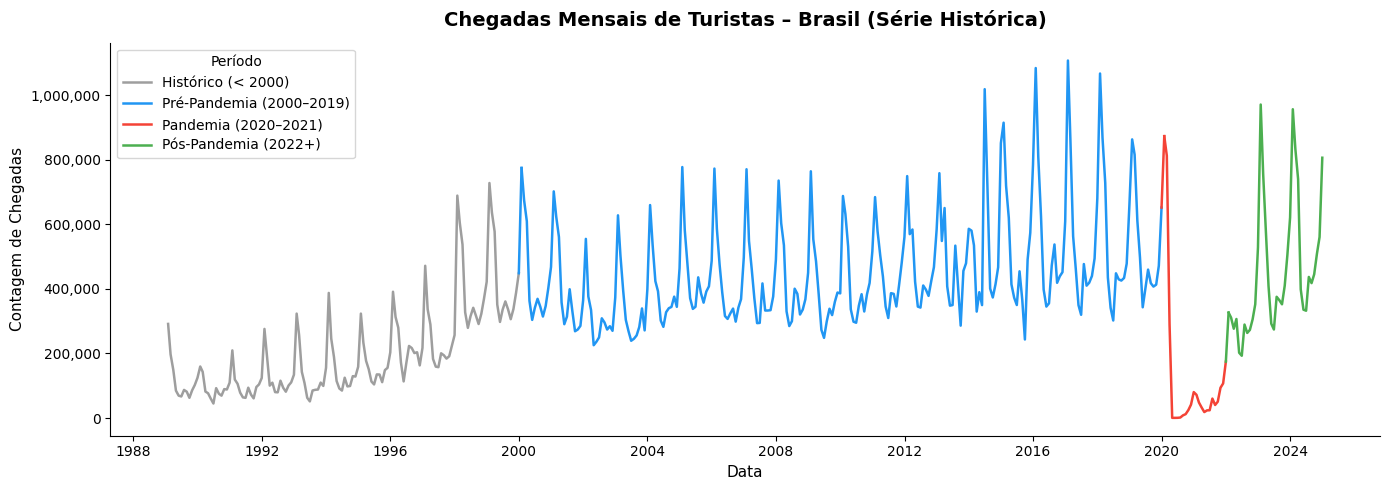

In [19]:
period_colors = {
    'Histórico (< 2000)': '#9e9e9e',
    'Pré-Pandemia (2000–2019)': '#2196f3',
    'Pandemia (2020–2021)': '#f44336',
    'Pós-Pandemia (2022+)': '#4caf50',
}

fig, ax = plt.subplots(figsize=(14, 5))

for period, color in period_colors.items():
    segment = monthly_df[monthly_df['period'] == period]
    if segment.empty:
        continue
    ax.plot(
        segment.index,
        segment['arrival_count'],
        color=color,
        linewidth=1.8,
        label=period,
    )

# Costura segmentos consecutivos para evitar lacunas visuais nas transições
for i in range(len(monthly_df) - 1):
    curr, nxt = monthly_df.iloc[i], monthly_df.iloc[i + 1]
    if curr['period'] != nxt['period']:
        ax.plot(
            [monthly_df.index[i], monthly_df.index[i + 1]],
            [curr['arrival_count'], nxt['arrival_count']],
            color=period_colors[nxt['period']],
            linewidth=1.8,
        )

ax.set_title(
    'Chegadas Mensais de Turistas – Brasil (Série Histórica)',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Data', fontsize=11)
ax.set_ylabel('Contagem de Chegadas', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='Período', frameon=True)
sns.despine()
plt.tight_layout()

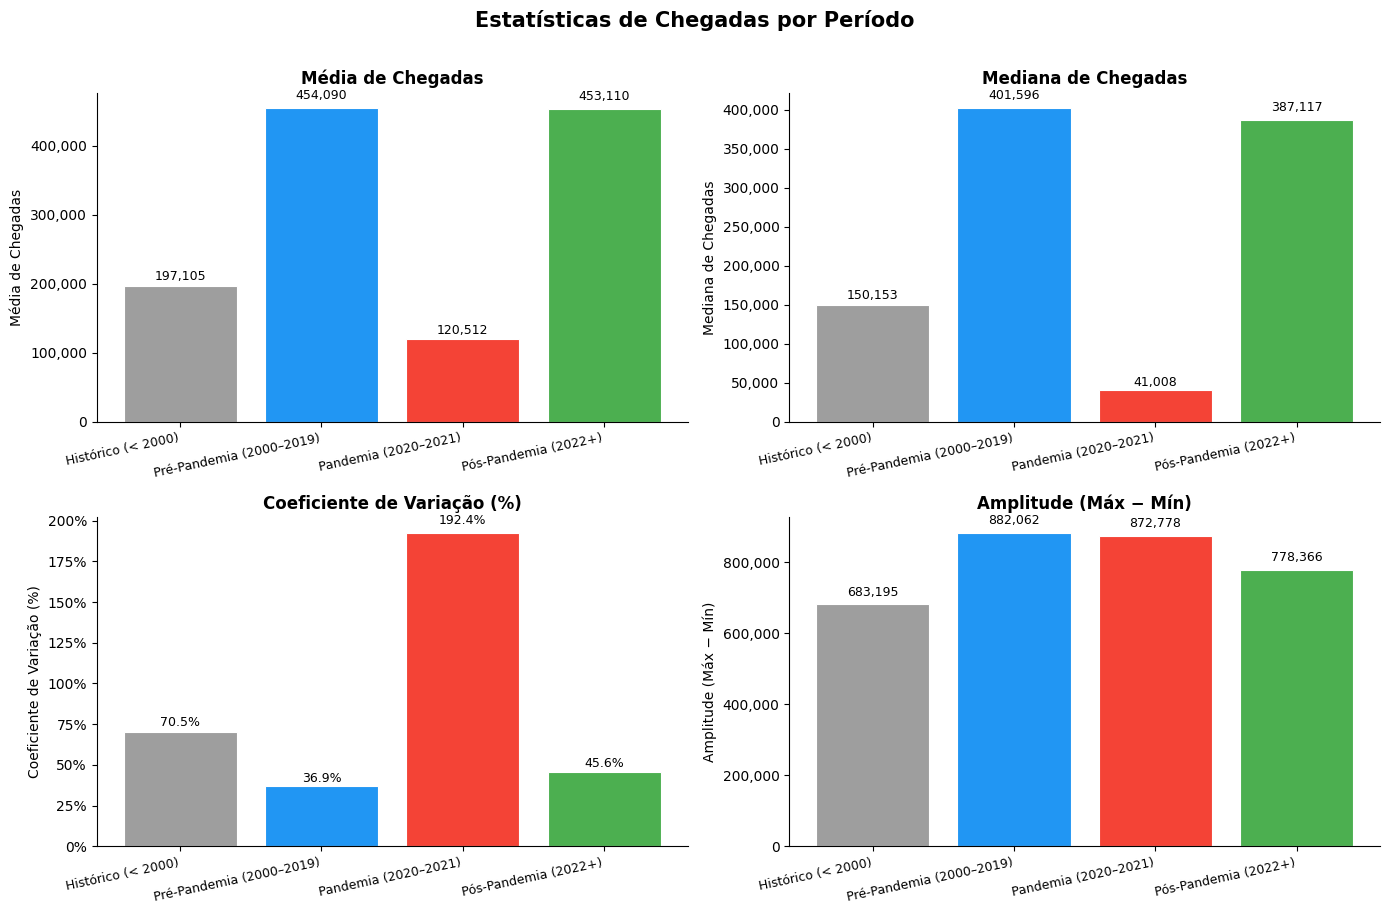

In [20]:
period_order = [
    'Histórico (< 2000)',
    'Pré-Pandemia (2000–2019)',
    'Pandemia (2020–2021)',
    'Pós-Pandemia (2022+)',
]
period_colors_list = [period_colors[p] for p in period_order]

period_stats = (
    monthly_df
    .groupby('period')['arrival_count']
    .agg(
        mean='mean',
        median='median',
        cv=lambda x: x.std() / x.mean() * 100,
        range=lambda x: x.max() - x.min(),
    )
    .reindex(period_order)
)

metrics = [
    ('mean', 'Média de Chegadas', lambda v: f'{int(v):,}'),
    ('median', 'Mediana de Chegadas', lambda v: f'{int(v):,}'),
    ('cv', 'Coeficiente de Variação (%)', lambda v: f'{v:.1f}%'),
    ('range', 'Amplitude (Máx − Mín)', lambda v: f'{int(v):,}'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Estatísticas de Chegadas por Período', fontsize=15, fontweight='bold', y=1.01)

for ax, (col, title, fmt) in zip(axes.flat, metrics):
    bars = ax.bar(
        range(len(period_order)),
        period_stats[col],
        color=period_colors_list,
        edgecolor='white',
        linewidth=0.8,
    )
    for bar, val in zip(bars, period_stats[col]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.02,
            fmt(val),
            ha='center',
            va='bottom',
            fontsize=9,
        )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(title, fontsize=10)
    ax.set_xticks(range(len(period_order)))
    ax.set_xticklabels(period_order, rotation=12, ha='right', fontsize=9)
    is_cv = col == 'cv'
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(
            lambda x, _, _is_cv=is_cv: f'{x:.0f}%' if _is_cv else f'{x:,.0f}'
        )
    )
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

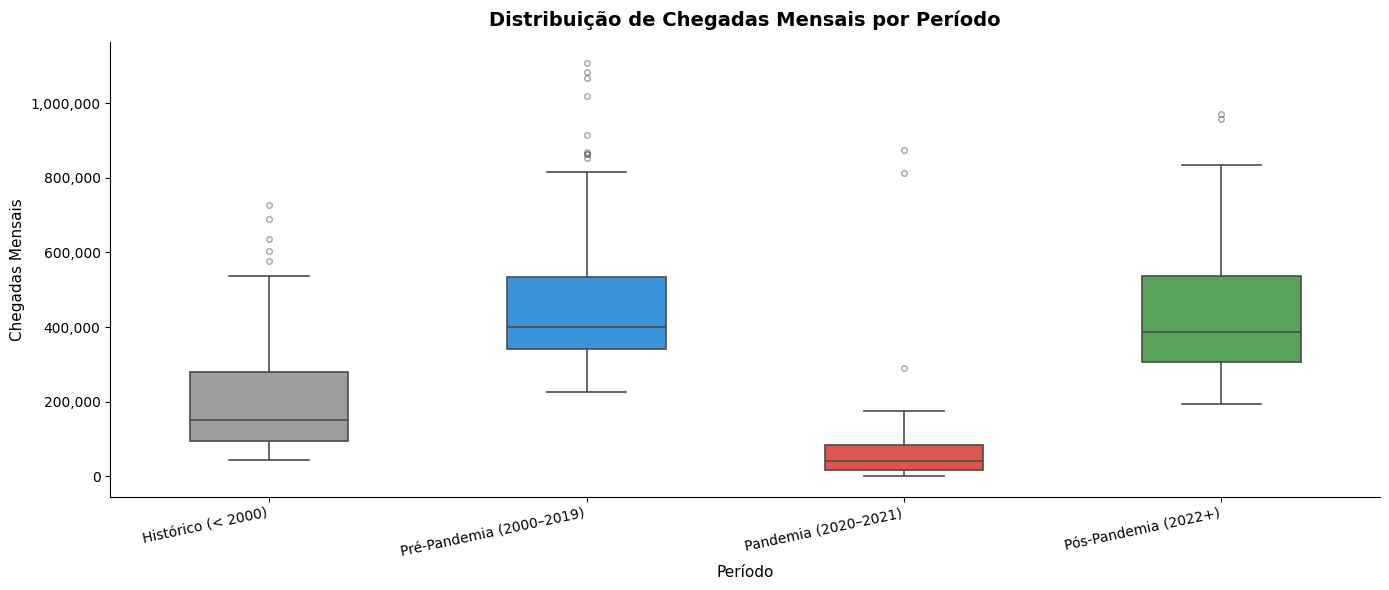

In [21]:
fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=monthly_df,
    x='period',
    y='arrival_count',
    hue='period',
    order=period_order,
    palette=period_colors,
    width=0.5,
    linewidth=1.2,
    flierprops=dict(marker='o', markersize=4, alpha=0.5),
    legend=False,
    ax=ax,
)

ax.set_title(
    'Distribuição de Chegadas Mensais por Período', fontsize=14, fontweight='bold', pad=12
)
ax.set_xlabel('Período', fontsize=11)
ax.set_ylabel('Chegadas Mensais', fontsize=11)
ax.set_xticks(range(len(period_order)))
ax.set_xticklabels(period_order, rotation=12, ha='right', fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()
plt.show()

#### Tendência

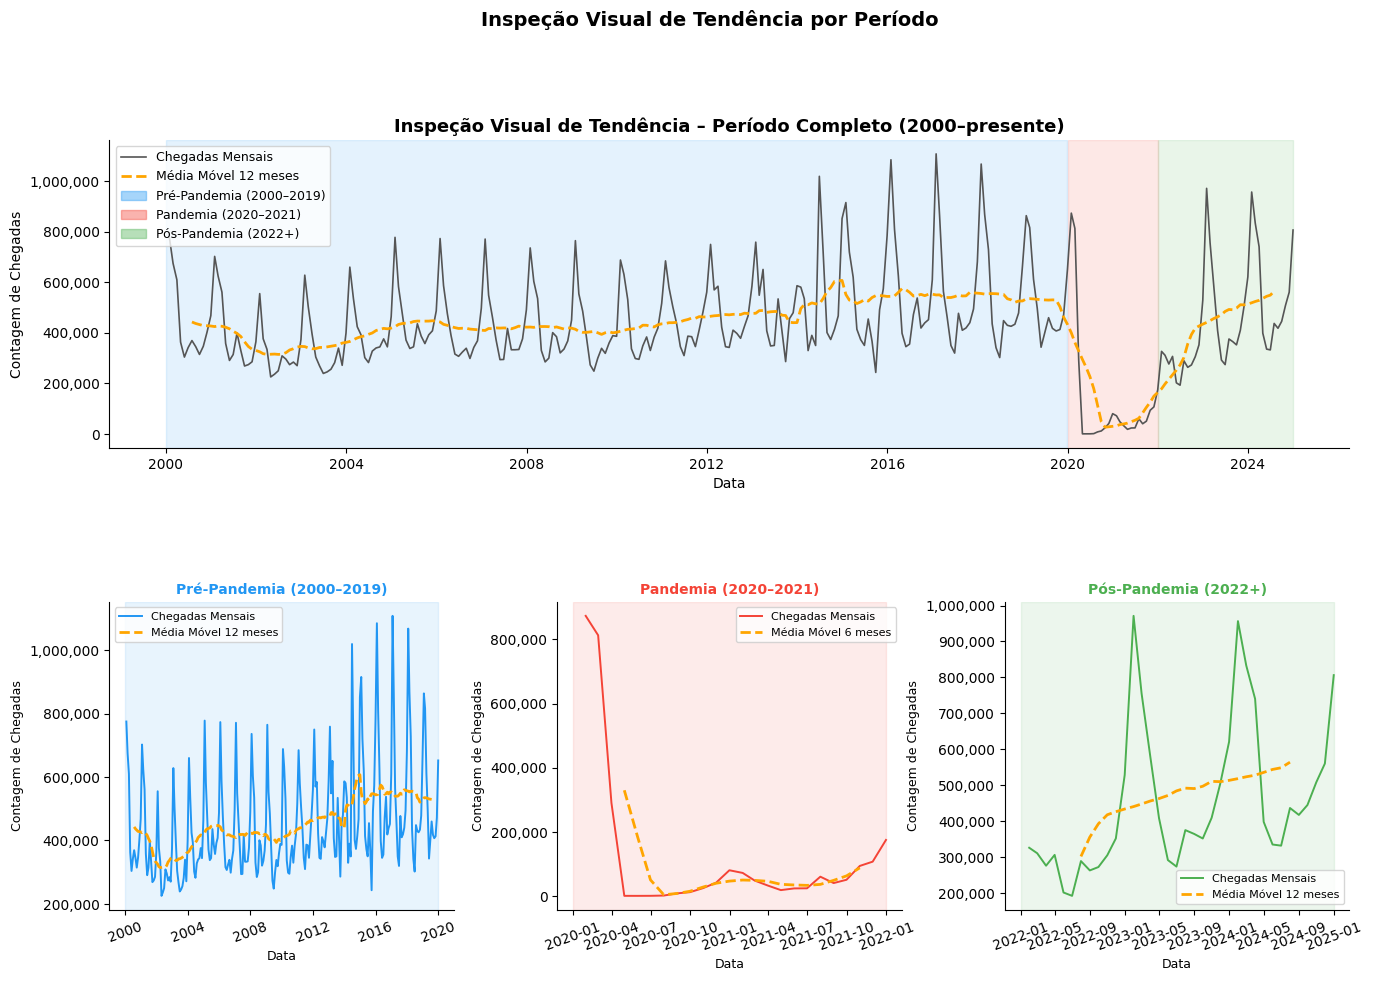

In [22]:
import matplotlib.patches as mpatches

trend_periods = [
    (
        'Pré-Pandemia (2000–2019)',
        pd.Timestamp('2000-01-01'),
        pd.Timestamp('2019-12-31'),
    ),
    ('Pandemia (2020–2021)', COVID_START, COVID_END),
    ('Pós-Pandemia (2022+)', pd.Timestamp('2022-01-01'), monthly_df.index[-1]),
]

post_2000 = monthly_df[monthly_df['period'] != 'Histórico (< 2000)']

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3, hspace=0.5, wspace=0.3)

# Painel superior: período completo pós-2000 abrangendo 3 colunas
ax_full = fig.add_subplot(gs[0, :])

ax_full.plot(
    post_2000.index,
    post_2000['arrival_count'],
    color='#555555',
    linewidth=1.2,
    label='Chegadas Mensais',
)

rolling_full = post_2000['arrival_count'].rolling(12, center=True).mean()
ax_full.plot(
    post_2000.index,
    rolling_full,
    color='orange',
    linewidth=2,
    linestyle='--',
    label='Média Móvel 12 meses',
)

for period, start, end in trend_periods:
    ax_full.axvspan(start, end, alpha=0.12, color=period_colors[period])

line_handles, _ = ax_full.get_legend_handles_labels()
span_handles = [
    mpatches.Patch(color=period_colors[p], alpha=0.4, label=p)
    for p, _, _ in trend_periods
]
ax_full.legend(handles=line_handles + span_handles, fontsize=9, frameon=True)
ax_full.set_title(
    'Inspeção Visual de Tendência – Período Completo (2000–presente)',
    fontsize=13,
    fontweight='bold',
)
ax_full.set_xlabel('Data', fontsize=10)
ax_full.set_ylabel('Contagem de Chegadas', fontsize=10)
ax_full.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine(ax=ax_full)

# Painéis inferiores: um subgráfico por período
for col_idx, (period, start, end) in enumerate(trend_periods):
    ax = fig.add_subplot(gs[1, col_idx])
    color = period_colors[period]

    segment = monthly_df[(monthly_df.index >= start) & (monthly_df.index <= end)]

    ax.plot(
        segment.index,
        segment['arrival_count'],
        color=color,
        linewidth=1.4,
        label='Chegadas Mensais',
    )
    ax.axvspan(start, end, alpha=0.1, color=color)

    # A pandemia (~24 obs) é curta demais para janela centrada de 12 meses
    window = 6 if len(segment) < 36 else 12
    rolling = segment['arrival_count'].rolling(window, center=True).mean()
    ax.plot(
        segment.index,
        rolling,
        color='orange',
        linewidth=2,
        linestyle='--',
        label=f'Média Móvel {window} meses',
    )

    ax.set_title(period, fontsize=10, fontweight='bold', color=color)
    ax.set_xlabel('Data', fontsize=9)
    ax.set_ylabel('Contagem de Chegadas', fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.legend(fontsize=8, frameon=True)
    ax.tick_params(axis='x', rotation=20)
    sns.despine(ax=ax)

plt.suptitle(
    'Inspeção Visual de Tendência por Período', fontsize=14, fontweight='bold', y=1.01
)
plt.show()

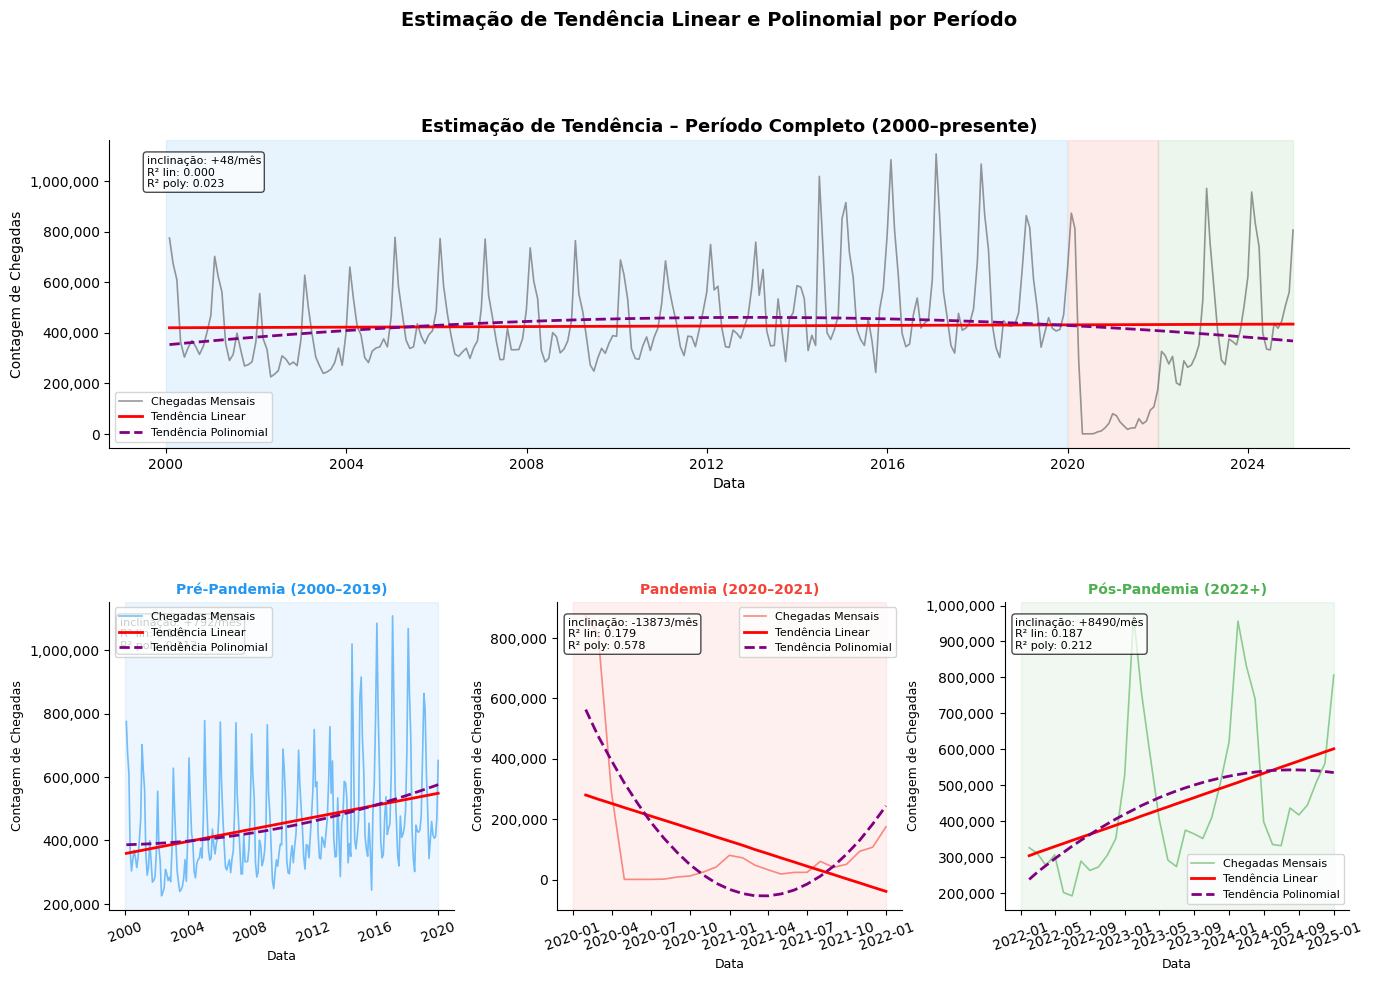

                                 Inclinação Linear (chegadas/mês) R² Linear R² Polinomial
Período                                                                                  
Período Completo (2000–presente)                            +48.0    0.0004        0.0233
Pré-Pandemia (2000–2019)                                   +791.8    0.1079        0.1133
Pandemia (2020–2021)                                     -13872.5    0.1790        0.5778
Pós-Pandemia (2022+)                                      +8489.8    0.1870        0.2118


In [23]:
def fit_trends(series):
    """Retorna (modelo_linear, modelo_polinomial, poly_features, t_index, stats_dict)."""
    t = np.arange(len(series)).reshape(-1, 1)
    y = series.values

    lin = LinearRegression().fit(t, y)

    pf = PolynomialFeatures(degree=2)
    poly = LinearRegression().fit(pf.fit_transform(t), y)

    stats = {
        'slope': lin.coef_[0],
        'r2_lin': lin.score(t, y),
        'r2_poly': poly.score(pf.fit_transform(t), y),
    }
    return lin, poly, pf, t, stats


def plot_trend_panel(ax, segment, period, color):
    lin, poly, pf, t, stats = fit_trends(segment['arrival_count'])

    ax.plot(
        segment.index,
        segment['arrival_count'],
        color=color,
        linewidth=1.2,
        alpha=0.6,
        label='Chegadas Mensais',
    )
    ax.plot(
        segment.index, lin.predict(t), color='red', linewidth=2, label='Tendência Linear'
    )
    ax.plot(
        segment.index,
        poly.predict(pf.fit_transform(t)),
        color='purple',
        linewidth=2,
        linestyle='--',
        label='Tendência Polinomial',
    )

    ax.annotate(
        f'inclinação: {stats["slope"]:+.0f}/mês\nR² lin: {stats["r2_lin"]:.3f}\nR² poly: {stats["r2_poly"]:.3f}',
        xy=(0.03, 0.95),
        xycoords='axes fraction',
        va='top',
        fontsize=8,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7),
    )
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.legend(fontsize=8, frameon=True)
    sns.despine(ax=ax)
    return stats


post_2000 = monthly_df[monthly_df['period'] != 'Histórico (< 2000)']

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3, hspace=0.5, wspace=0.3)

# Painel superior: período completo pós-2000
ax_full = fig.add_subplot(gs[0, :])
full_stats = plot_trend_panel(ax_full, post_2000, 'Período Completo', '#555555')

for period, start, end in trend_periods:
    ax_full.axvspan(start, end, alpha=0.1, color=period_colors[period])

ax_full.set_title(
    'Estimação de Tendência – Período Completo (2000–presente)', fontsize=13, fontweight='bold'
)
ax_full.set_xlabel('Data', fontsize=10)
ax_full.set_ylabel('Contagem de Chegadas', fontsize=10)

# Painéis inferiores: um por período
all_stats = [('Período Completo (2000–presente)', full_stats)]

for col_idx, (period, start, end) in enumerate(trend_periods):
    ax = fig.add_subplot(gs[1, col_idx])
    color = period_colors[period]

    segment = monthly_df[(monthly_df.index >= start) & (monthly_df.index <= end)]
    stats = plot_trend_panel(ax, segment, period, color)
    ax.axvspan(start, end, alpha=0.08, color=color)
    ax.set_title(period, fontsize=10, fontweight='bold', color=color)
    ax.set_xlabel('Data', fontsize=9)
    ax.set_ylabel('Contagem de Chegadas', fontsize=9)
    ax.tick_params(axis='x', rotation=20)

    all_stats.append((period, stats))

plt.suptitle(
    'Estimação de Tendência Linear e Polinomial por Período',
    fontsize=14,
    fontweight='bold',
    y=1.01,
)
plt.show()

# Tabela resumo
summary = pd.DataFrame(
    [
        (p, f'{s["slope"]:+.1f}', f'{s["r2_lin"]:.4f}', f'{s["r2_poly"]:.4f}')
        for p, s in all_stats
    ],
    columns=['Período', 'Inclinação Linear (chegadas/mês)', 'R² Linear', 'R² Polinomial'],
).set_index('Período')

print(summary.to_string())

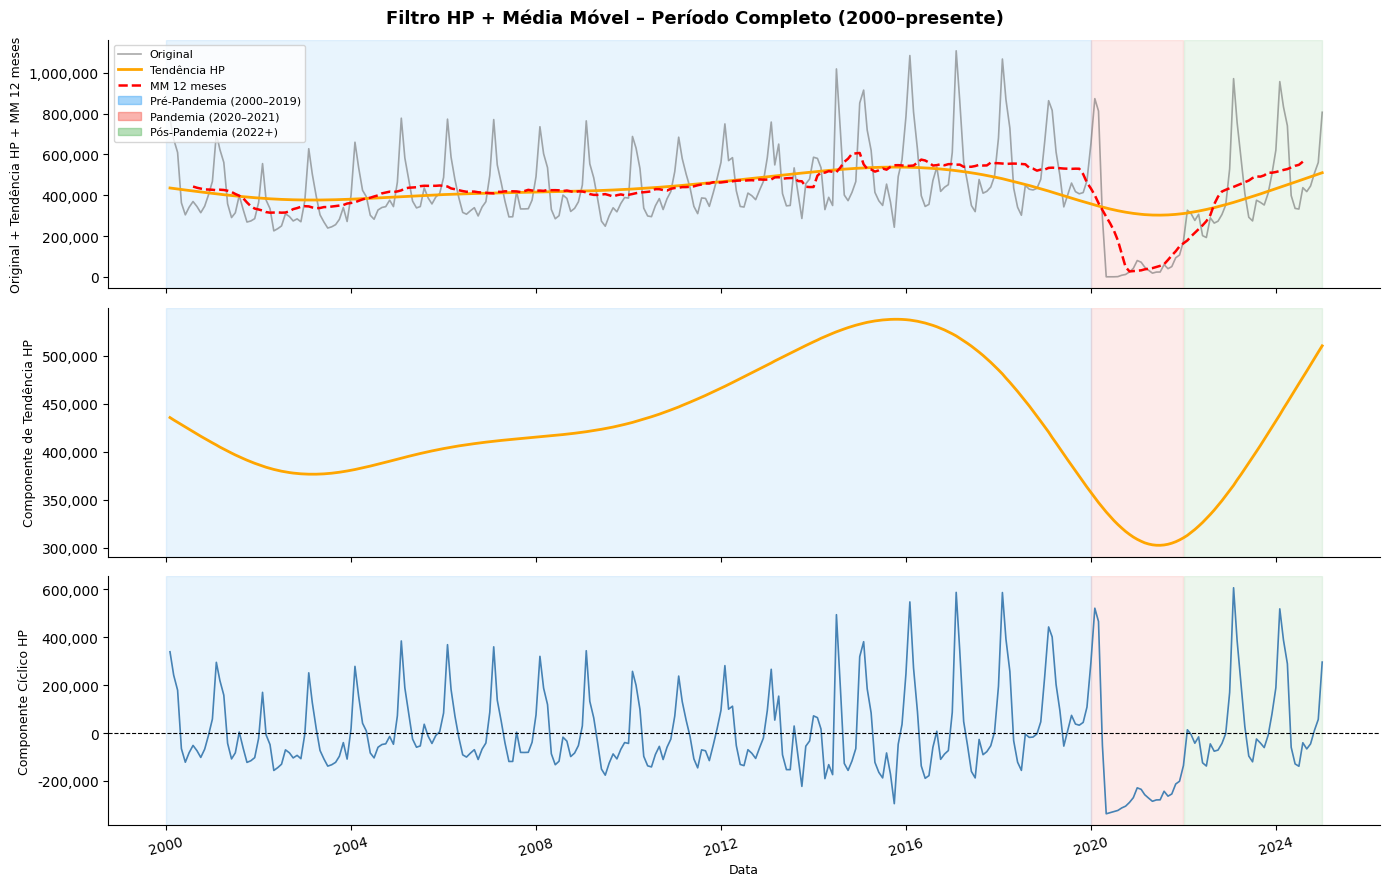

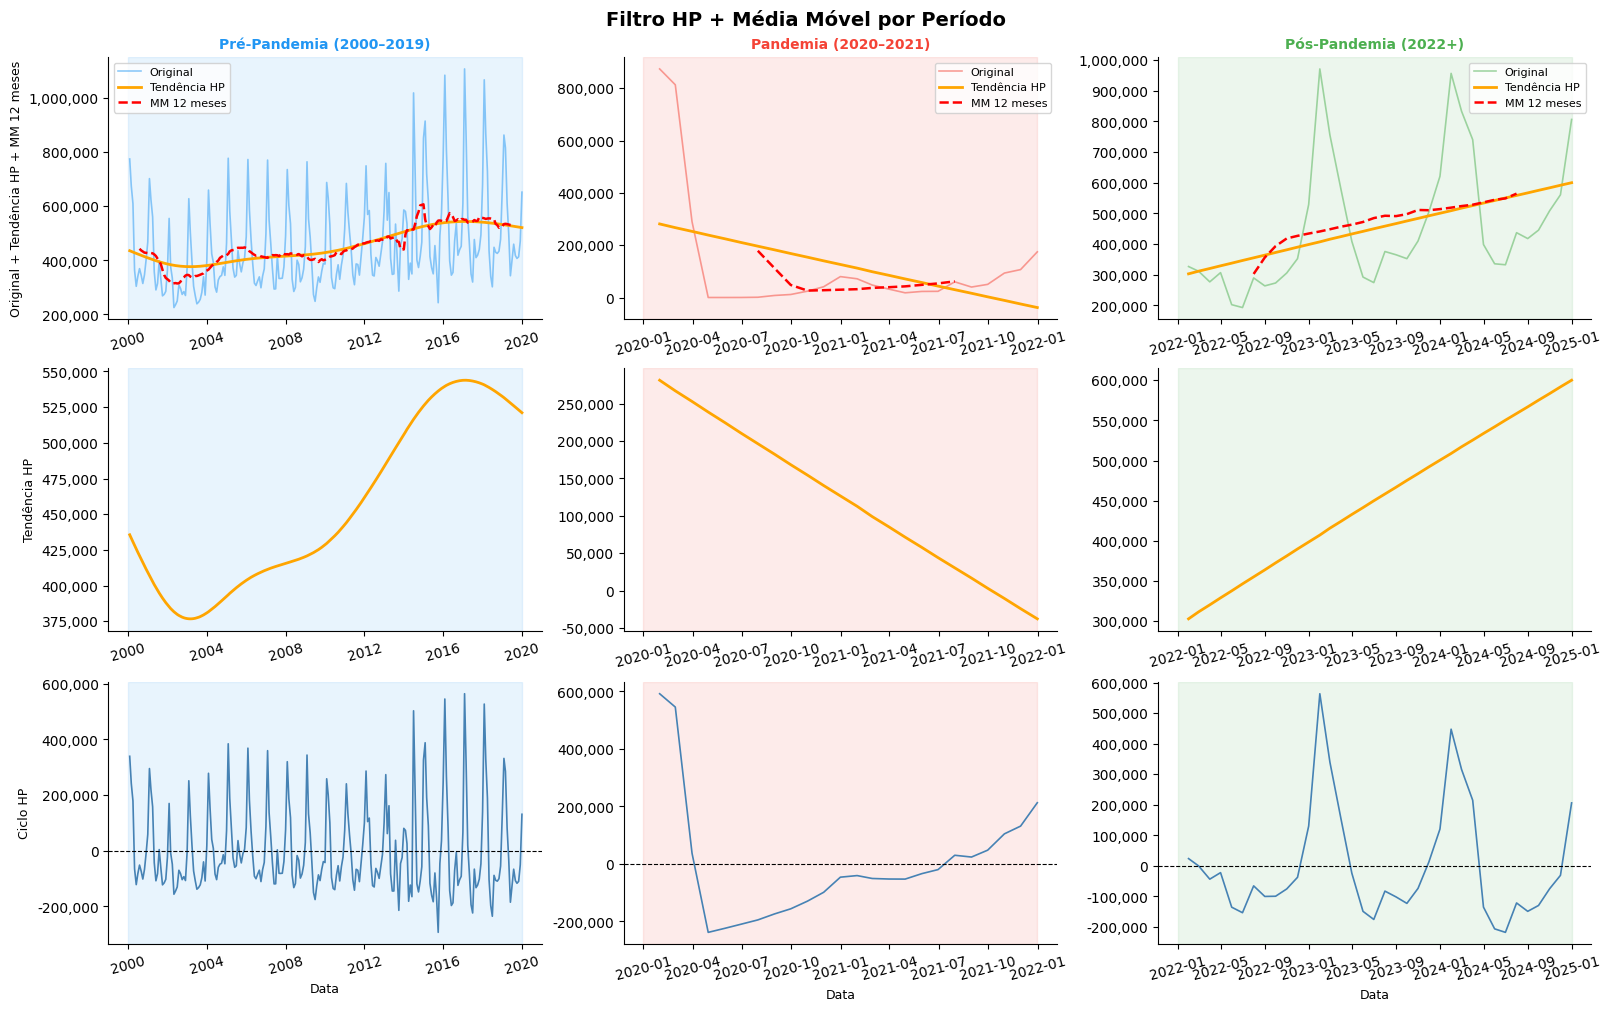

In [24]:
HP_LAMBDA = 129600  # padrão para dados mensais


def plot_hp_panel(axes, segment, color, show_ylabel=True):
    series = segment['arrival_count'].dropna()
    cycle, trend = hpfilter(series, lamb=HP_LAMBDA)
    ma12 = series.rolling(12, center=True).mean()

    axes[0].plot(
        series.index, series, color=color, linewidth=1.2, alpha=0.5, label='Original'
    )
    axes[0].plot(series.index, trend, color='orange', linewidth=2, label='Tendência HP')
    axes[0].plot(
        series.index, ma12, color='red', linewidth=1.8, linestyle='--', label='MM 12 meses'
    )
    axes[0].legend(fontsize=8, frameon=True)

    axes[1].plot(series.index, trend, color='orange', linewidth=2)
    axes[2].plot(series.index, cycle, color='steelblue', linewidth=1.2)
    axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[2].set_xlabel('Data', fontsize=9)

    for ax in axes:
        if show_ylabel:
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
        ax.tick_params(axis='x', rotation=15)
        sns.despine(ax=ax)


post_2000 = monthly_df[monthly_df['period'] != 'Histórico (< 2000)']

fig_full, axes_full = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fig_full.suptitle(
    'Filtro HP + Média Móvel – Período Completo (2000–presente)',
    fontsize=13,
    fontweight='bold',
)

plot_hp_panel(axes_full, post_2000, '#555555')

for period, start, end in trend_periods:
    for ax in axes_full:
        ax.axvspan(start, end, alpha=0.1, color=period_colors[period])

span_handles = [
    mpatches.Patch(color=period_colors[p], alpha=0.4, label=p)
    for p, _, _ in trend_periods
]
existing_handles, existing_labels = axes_full[0].get_legend_handles_labels()
axes_full[0].legend(
    handles=existing_handles + span_handles,
    labels=existing_labels + [p for p, _, _ in trend_periods],
    fontsize=8,
    frameon=True,
)

row_labels_full = [
    'Original + Tendência HP + MM 12 meses',
    'Componente de Tendência HP',
    'Componente Cíclico HP',
]
for ax, label in zip(axes_full, row_labels_full):
    ax.set_ylabel(label, fontsize=9)

plt.tight_layout()
plt.show()

# Grade 3×3: um subgráfico por período
fig, axes_grid = plt.subplots(3, 3, figsize=(16, 10), constrained_layout=True)
fig.suptitle('Filtro HP + Média Móvel por Período', fontsize=14, fontweight='bold')

row_labels = ['Original + Tendência HP + MM 12 meses', 'Tendência HP', 'Ciclo HP']

for col_idx, (period, start, end) in enumerate(trend_periods):
    color = period_colors[period]
    segment = monthly_df[(monthly_df.index >= start) & (monthly_df.index <= end)]
    col_axes = axes_grid[:, col_idx]

    plot_hp_panel(col_axes, segment, color, show_ylabel=(col_idx == 0))

    col_axes[0].set_title(period, fontsize=10, fontweight='bold', color=color)
    for ax in col_axes:
        ax.axvspan(start, end, alpha=0.1, color=color)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

for row_idx, label in enumerate(row_labels):
    axes_grid[row_idx, 0].set_ylabel(label, fontsize=9)

plt.show()

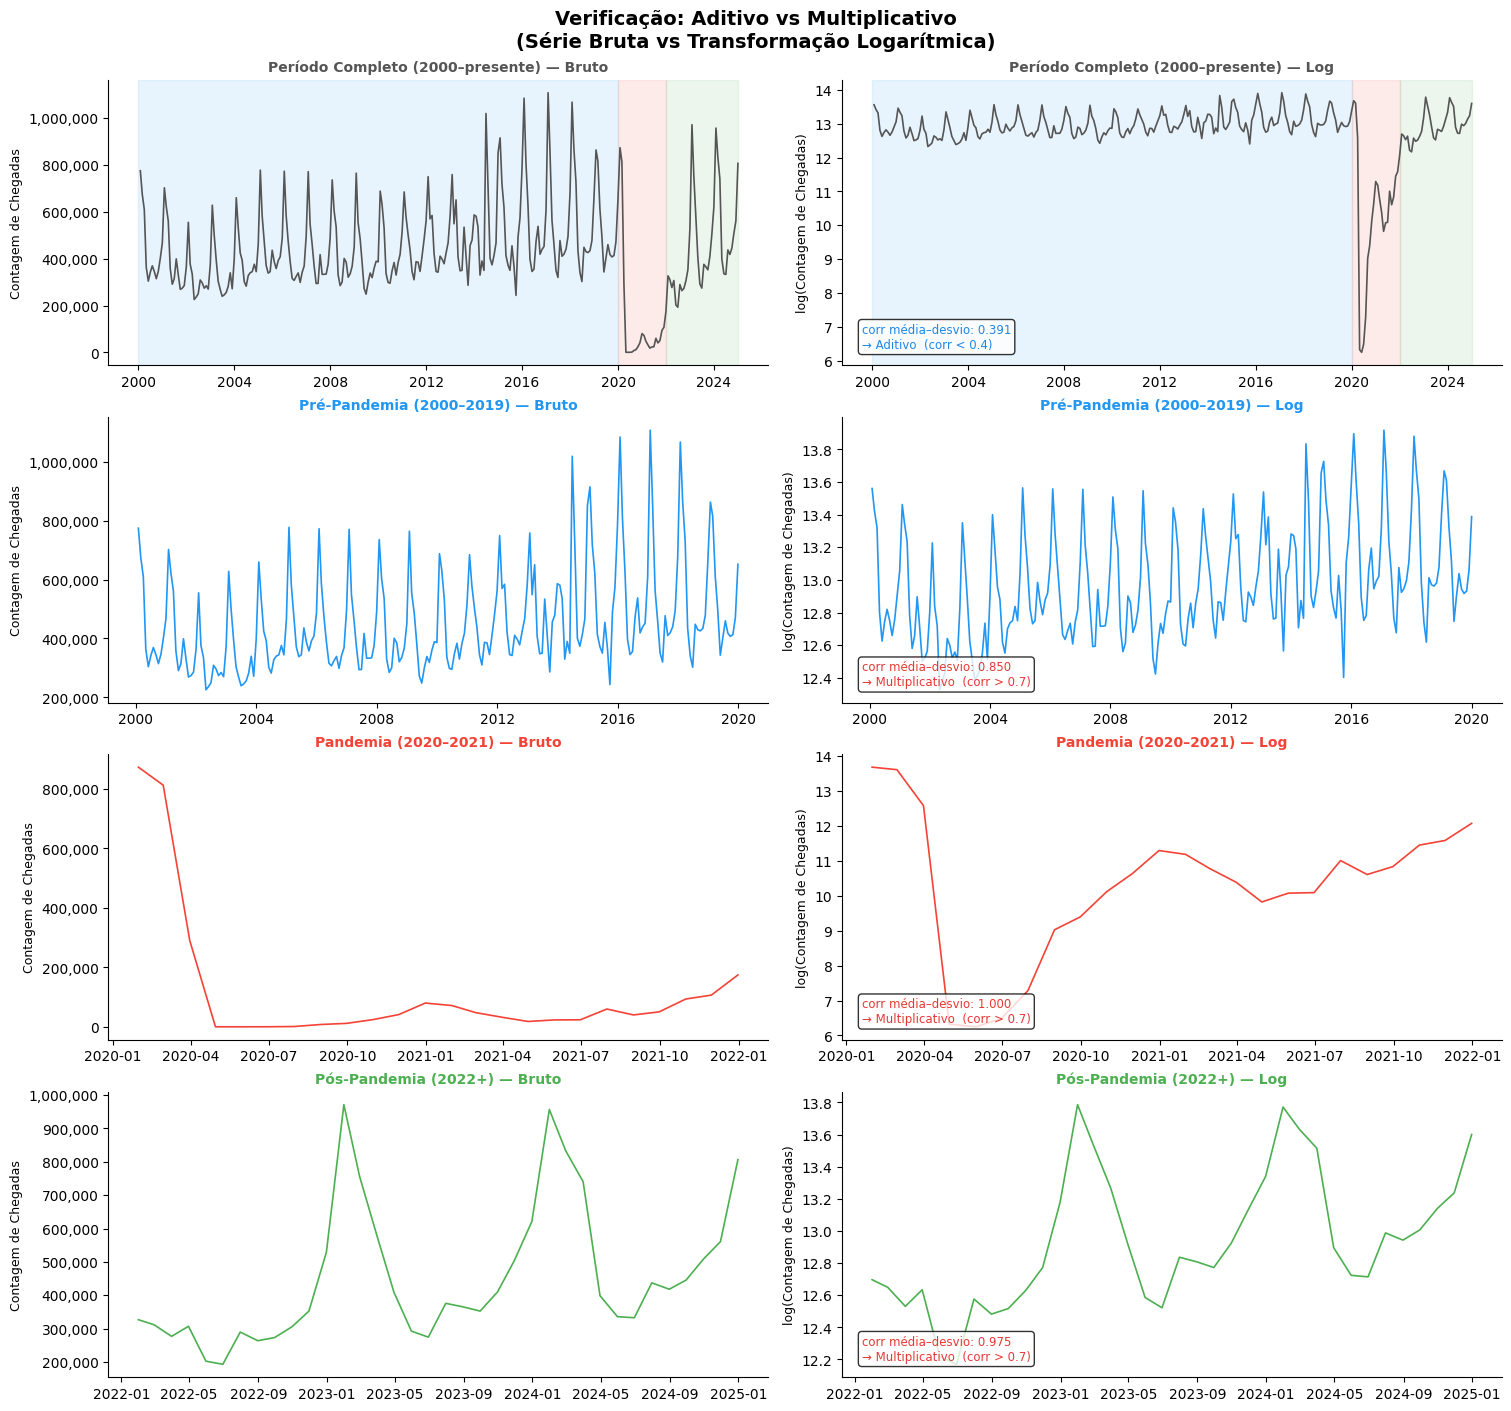

                                 Correlação Média–Desvio                     Veredicto
Período                                                                               
Período Completo (2000–presente)                   0.391         Aditivo  (corr < 0.4)
Pré-Pandemia (2000–2019)                           0.850  Multiplicativo  (corr > 0.7)
Pandemia (2020–2021)                               1.000  Multiplicativo  (corr > 0.7)
Pós-Pandemia (2022+)                               0.975  Multiplicativo  (corr > 0.7)


In [25]:
def additive_or_multiplicative(segment, label, color):
    """Verificação visual e quantitativa do tipo de decomposição."""
    series = segment['arrival_count'].replace(0, np.nan).dropna()
    log_series = np.log(series)

    annual = series.resample('YE').agg(['mean', 'std']).dropna()
    corr = annual['mean'].corr(annual['std'])

    if corr > 0.7:
        verdict = 'Multiplicativo  (corr > 0.7)'
        verdict_color = '#e53935'
    elif corr < 0.4:
        verdict = 'Aditivo  (corr < 0.4)'
        verdict_color = '#1e88e5'
    else:
        verdict = 'Ambíguo  (0.4 ≤ corr ≤ 0.7)'
        verdict_color = '#fb8c00'

    return {
        'label': label,
        'corr': corr,
        'verdict': verdict,
        'verdict_color': verdict_color,
        'series': series,
        'log_series': log_series,
        'color': color,
    }


non_legacy_periods = [
    (
        'Pré-Pandemia (2000–2019)',
        pd.Timestamp('2000-01-01'),
        pd.Timestamp('2019-12-31'),
    ),
    ('Pandemia (2020–2021)', COVID_START, COVID_END),
    ('Pós-Pandemia (2022+)', pd.Timestamp('2022-01-01'), monthly_df.index[-1]),
]

post_2000 = monthly_df[monthly_df['period'] != 'Histórico (< 2000)']

results = [
    additive_or_multiplicative(post_2000, 'Período Completo (2000–presente)', '#555555')
]
for period, start, end in non_legacy_periods:
    seg = monthly_df[(monthly_df.index >= start) & (monthly_df.index <= end)]
    results.append(additive_or_multiplicative(seg, period, period_colors[period]))

# Grade 4×2: bruto vs logarítmico para cada série
fig, axes = plt.subplots(4, 2, figsize=(15, 14), constrained_layout=True)
fig.suptitle(
    'Verificação: Aditivo vs Multiplicativo\n(Série Bruta vs Transformação Logarítmica)',
    fontsize=14,
    fontweight='bold',
)

for row, res in enumerate(results):
    ax_raw, ax_log = axes[row, 0], axes[row, 1]
    color = res['color']

    ax_raw.plot(res['series'].index, res['series'], color=color, linewidth=1.2)
    ax_raw.set_title(
        f'{res["label"]} — Bruto', fontsize=10, fontweight='bold', color=color
    )
    ax_raw.set_ylabel('Contagem de Chegadas', fontsize=9)
    ax_raw.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    sns.despine(ax=ax_raw)

    ax_log.plot(res['log_series'].index, res['log_series'], color=color, linewidth=1.2)
    ax_log.set_title(
        f'{res["label"]} — Log', fontsize=10, fontweight='bold', color=color
    )
    ax_log.set_ylabel('log(Contagem de Chegadas)', fontsize=9)
    ax_log.annotate(
        f'corr média–desvio: {res["corr"]:.3f}\n→ {res["verdict"]}',
        xy=(0.03, 0.05),
        xycoords='axes fraction',
        va='bottom',
        fontsize=8.5,
        color=res['verdict_color'],
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8),
    )
    sns.despine(ax=ax_log)

    if res['label'] == 'Período Completo (2000–presente)':
        for period, start, end in non_legacy_periods:
            ax_raw.axvspan(start, end, alpha=0.1, color=period_colors[period])
            ax_log.axvspan(start, end, alpha=0.1, color=period_colors[period])

plt.show()

# Tabela resumo
summary_add = pd.DataFrame(
    [(r['label'], f'{r["corr"]:.3f}', r['verdict']) for r in results],
    columns=['Período', 'Correlação Média–Desvio', 'Veredicto'],
).set_index('Período')

print(summary_add.to_string())

#### Sazonalidade

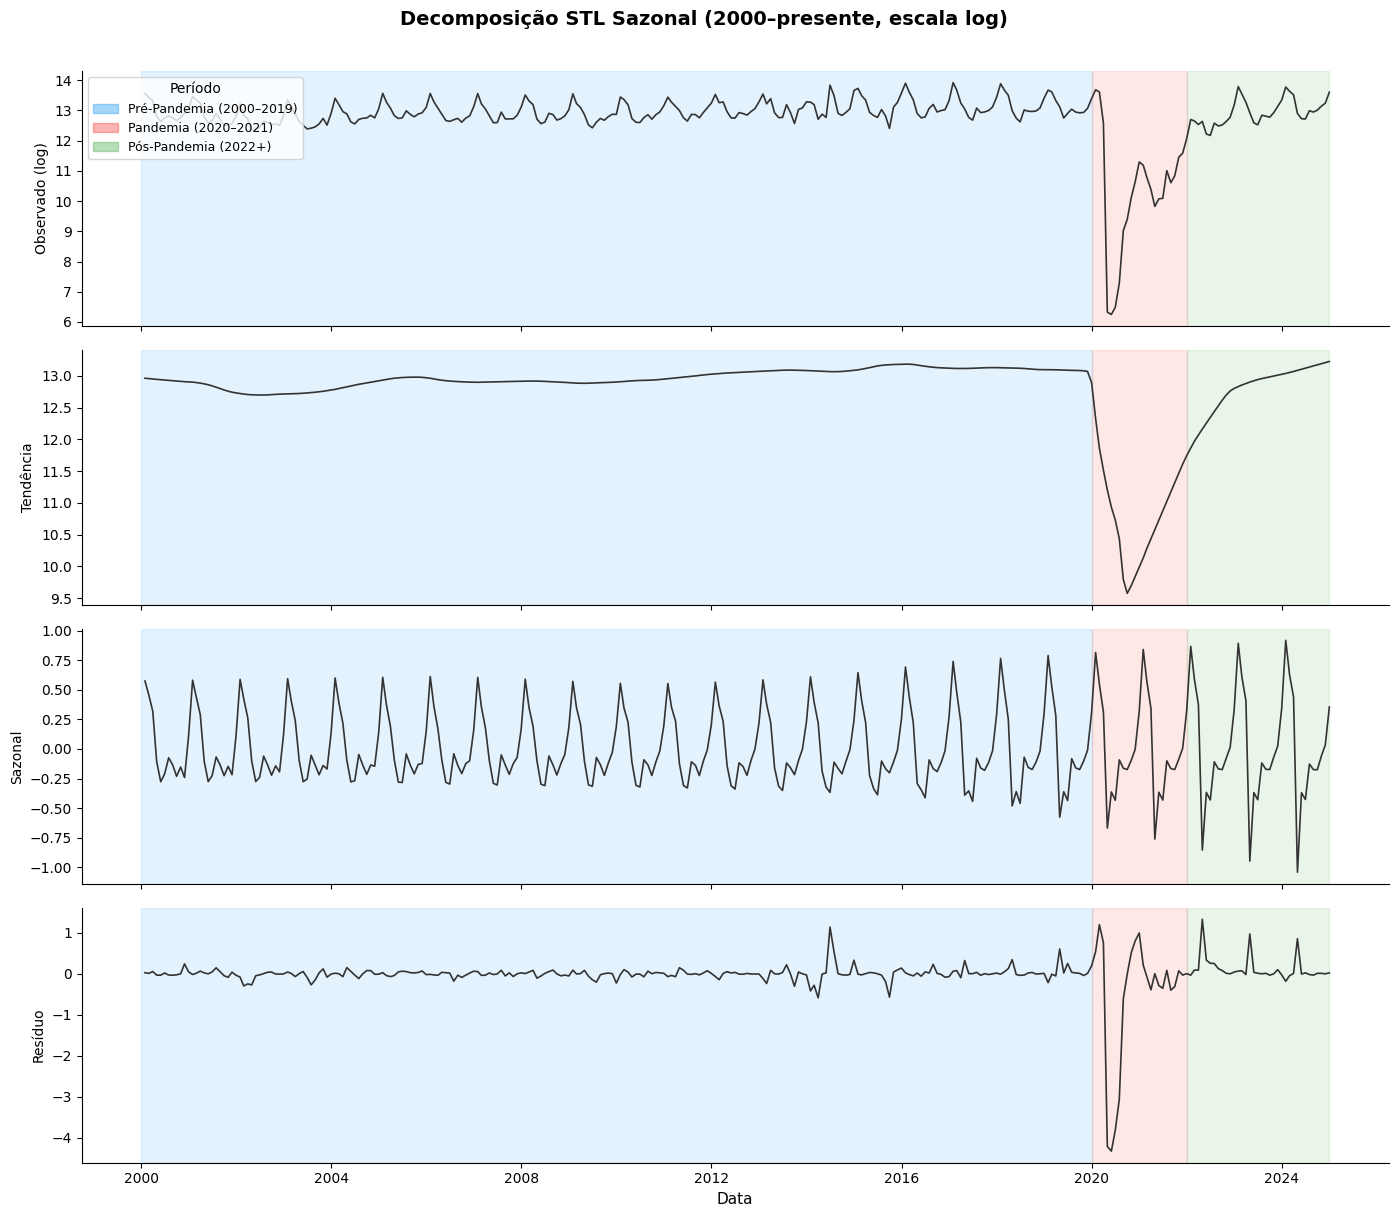

In [26]:
stl_series = np.log(
    monthly_df.loc[monthly_df['period'] != 'Histórico (< 2000)', 'arrival_count']
)

stl = STL(stl_series, period=12, seasonal=13, robust=True)
result = stl.fit()

components = [
    ('observed', 'Observado (log)', result.observed),
    ('trend', 'Tendência', result.trend),
    ('seasonal', 'Sazonal', result.seasonal),
    ('resid', 'Resíduo', result.resid),
]

period_spans = [
    (
        'Pré-Pandemia (2000–2019)',
        pd.Timestamp('2000-01-01'),
        pd.Timestamp('2019-12-31'),
    ),
    ('Pandemia (2020–2021)', COVID_START, COVID_END),
    ('Pós-Pandemia (2022+)', pd.Timestamp('2022-01-01'), stl_series.index[-1]),
]

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
fig.suptitle(
    'Decomposição STL Sazonal (2000–presente, escala log)',
    fontsize=14,
    fontweight='bold',
    y=1.01,
)

for ax, (_, label, component) in zip(axes, components):
    ax.plot(component.index, component.values, color='#333333', linewidth=1.2)

    for period, start, end in period_spans:
        ax.axvspan(start, end, alpha=0.12, color=period_colors[period], label=period)

    ax.set_ylabel(label, fontsize=10)
    sns.despine(ax=ax)

# Legenda compartilhada no subplot superior
handles = [
    plt.Rectangle((0, 0), 1, 1, color=period_colors[p], alpha=0.4)
    for p in [
        'Pré-Pandemia (2000–2019)',
        'Pandemia (2020–2021)',
        'Pós-Pandemia (2022+)',
    ]
]
labels = ['Pré-Pandemia (2000–2019)', 'Pandemia (2020–2021)', 'Pós-Pandemia (2022+)']
axes[0].legend(
    handles, labels, title='Período', loc='upper left', frameon=True, fontsize=9
)

axes[-1].set_xlabel('Data', fontsize=11)
plt.tight_layout()
plt.show()

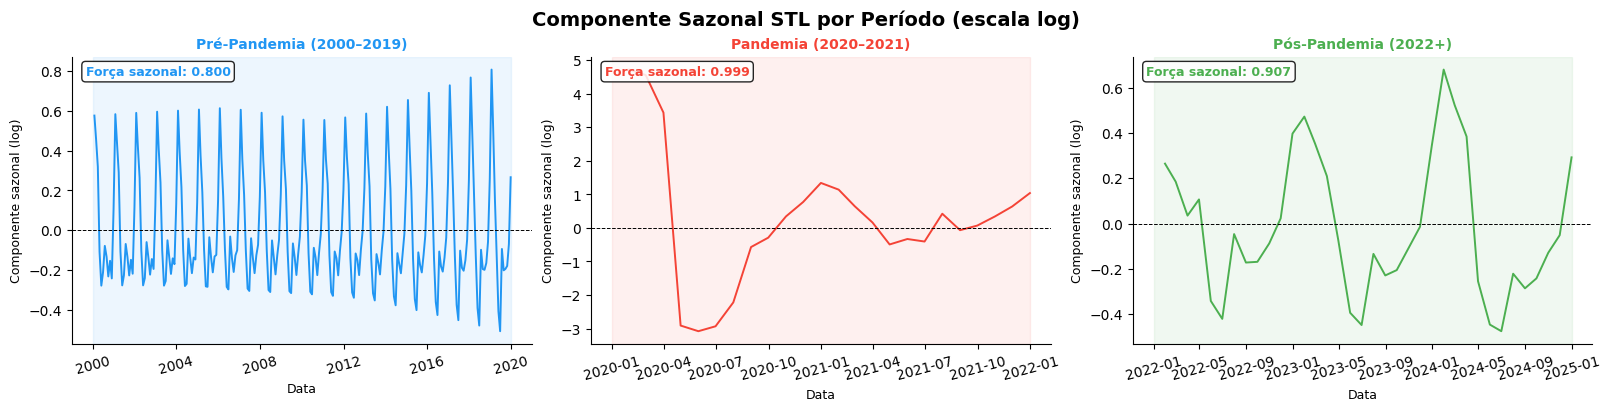

                                 Força Sazonal
Período                                       
Período Completo (2000–presente)        0.3466
Pré-Pandemia (2000–2019)                0.7998
Pandemia (2020–2021)                    0.9993
Pós-Pandemia (2022+)                    0.9069


In [27]:
def stl_seasonal_strength(result):
    """max(0, 1 - Var(resíduo) / Var(sazonal + resíduo))"""
    var_resid = np.var(result.resid)
    var_seasonal_resid = np.var(result.seasonal + result.resid)
    return max(0.0, 1 - var_resid / var_seasonal_resid)


seasonal_periods = [
    (
        'Pré-Pandemia (2000–2019)',
        pd.Timestamp('2000-01-01'),
        pd.Timestamp('2019-12-31'),
    ),
    ('Pandemia (2020–2021)', COVID_START, COVID_END),
    ('Pós-Pandemia (2022+)', pd.Timestamp('2022-01-01'), monthly_df.index[-1]),
]

post_2000 = monthly_df[monthly_df['period'] != 'Histórico (< 2000)']

full_series = np.log(post_2000['arrival_count'].replace(0, np.nan).dropna())
full_result = STL(full_series, period=12, seasonal=13, robust=True).fit()
full_strength = stl_seasonal_strength(full_result)

period_stl = {}
for period, start, end in seasonal_periods:
    seg = monthly_df[(monthly_df.index >= start) & (monthly_df.index <= end)]
    series = np.log(seg['arrival_count'].replace(0, np.nan).dropna())
    # Pandemia é curta demais para STL com seasonal=13; usa seasonal=7
    s_window = 7 if len(series) < 36 else 13
    result = STL(series, period=12, seasonal=s_window, robust=True).fit()
    period_stl[period] = dict(result=result, strength=stl_seasonal_strength(result))

# Componente sazonal por período (1×3)
fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
fig.suptitle(
    'Componente Sazonal STL por Período (escala log)', fontsize=14, fontweight='bold'
)

for ax, (period, start, end) in zip(axes, seasonal_periods):
    color = period_colors[period]
    res = period_stl[period]['result']
    fs = period_stl[period]['strength']

    ax.plot(res.seasonal.index, res.seasonal.values, color=color, linewidth=1.4)
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax.axvspan(start, end, alpha=0.08, color=color)

    ax.annotate(
        f'Força sazonal: {fs:.3f}',
        xy=(0.03, 0.97),
        xycoords='axes fraction',
        va='top',
        fontsize=9,
        color=color,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85),
    )
    ax.set_title(period, fontsize=10, fontweight='bold', color=color)
    ax.set_xlabel('Data', fontsize=9)
    ax.set_ylabel('Componente sazonal (log)', fontsize=9)
    ax.tick_params(axis='x', rotation=15)
    sns.despine(ax=ax)

plt.show()

# Tabela resumo
summary_seasonal = pd.DataFrame(
    [('Período Completo (2000–presente)', f'{full_strength:.4f}')]
    + [(p, f'{period_stl[p]["strength"]:.4f}') for p, _, _ in seasonal_periods],
    columns=['Período', 'Força Sazonal'],
).set_index('Período')

print(summary_seasonal.to_string())

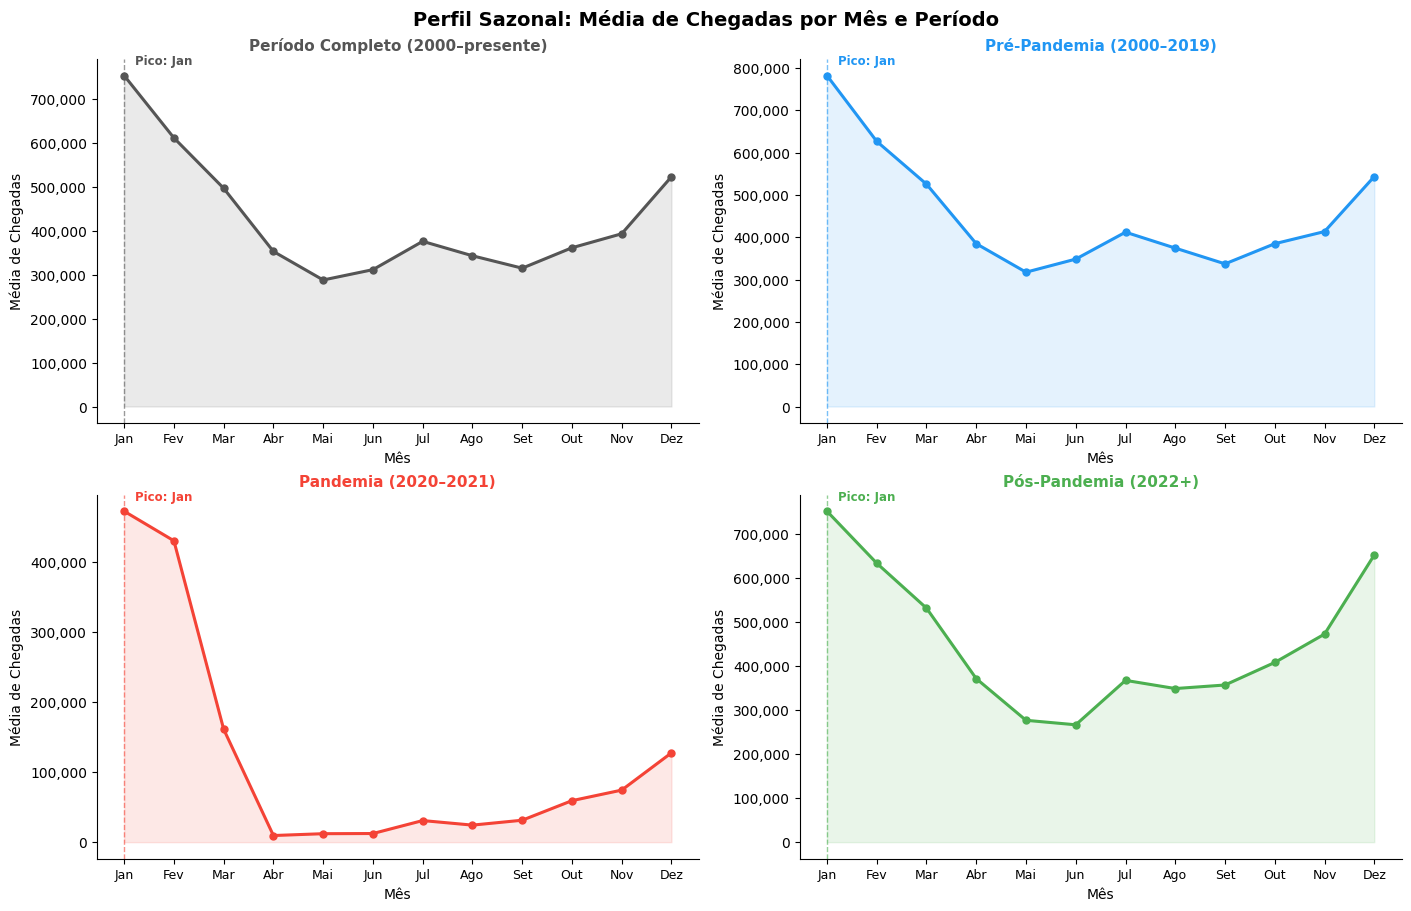

In [28]:
month_labels = [
    'Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun',
    'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez',
]

shape_panels = [
    (
        'Período Completo (2000–presente)',
        monthly_df[monthly_df['period'] != 'Histórico (< 2000)'],
        '#555555',
    ),
    (
        'Pré-Pandemia (2000–2019)',
        monthly_df[monthly_df['period'] == 'Pré-Pandemia (2000–2019)'],
        period_colors['Pré-Pandemia (2000–2019)'],
    ),
    (
        'Pandemia (2020–2021)',
        monthly_df[monthly_df['period'] == 'Pandemia (2020–2021)'],
        period_colors['Pandemia (2020–2021)'],
    ),
    (
        'Pós-Pandemia (2022+)',
        monthly_df[monthly_df['period'] == 'Pós-Pandemia (2022+)'],
        period_colors['Pós-Pandemia (2022+)'],
    ),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
fig.suptitle(
    'Perfil Sazonal: Média de Chegadas por Mês e Período', fontsize=14, fontweight='bold'
)

for ax, (label, segment, color) in zip(axes.flat, shape_panels):
    monthly_means = (
        segment['arrival_count']
        .groupby(segment.index.month)
        .mean()
        .reindex(range(1, 13))
    )

    ax.plot(
        range(1, 13),
        monthly_means.values,
        color=color,
        linewidth=2.2,
        marker='o',
        markersize=5,
    )
    ax.fill_between(range(1, 13), monthly_means.values, alpha=0.12, color=color)

    peak_month = monthly_means.idxmax()
    ax.axvline(peak_month, color=color, linewidth=1, linestyle='--', alpha=0.6)
    ax.annotate(
        f'Pico: {month_labels[peak_month - 1]}',
        xy=(peak_month, monthly_means[peak_month]),
        xytext=(8, 8),
        textcoords='offset points',
        fontsize=8.5,
        color=color,
        fontweight='bold',
    )

    ax.set_title(label, fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel('Mês', fontsize=10)
    ax.set_ylabel('Média de Chegadas', fontsize=10)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels, fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    sns.despine(ax=ax)

plt.show()

#### Estacionariedade

RESULTADOS DOS TESTES DE ESTACIONARIEDADE — ADF + KPSS
ADF  H0: raiz unitária (não estacionária) → rejeitar (p < 0,05) = estacionária
KPSS H0: estacionária                     → rejeitar (p < 0,05) = não estacionária
                 Período        Transformação  p ADF ADF estacionária  p KPSS KPSS estacionária Veredicto conjunto
Completo (2000–presente)                Bruto 0.0610                ✗  0.1000                 ✓            Ambígua
Completo (2000–presente)                  Log 0.0255                ✓  0.1000                 ✓       Estacionária
Completo (2000–presente)              Diff(1) 0.0000                ✓  0.1000                 ✓       Estacionária
Completo (2000–presente)        Log + Diff(1) 0.0000                ✓  0.1000                 ✓       Estacionária
Completo (2000–presente)             Diff(12) 0.0037                ✓  0.1000                 ✓       Estacionária
Completo (2000–presente)       Log + Diff(12) 0.0054                ✓  0.1000                

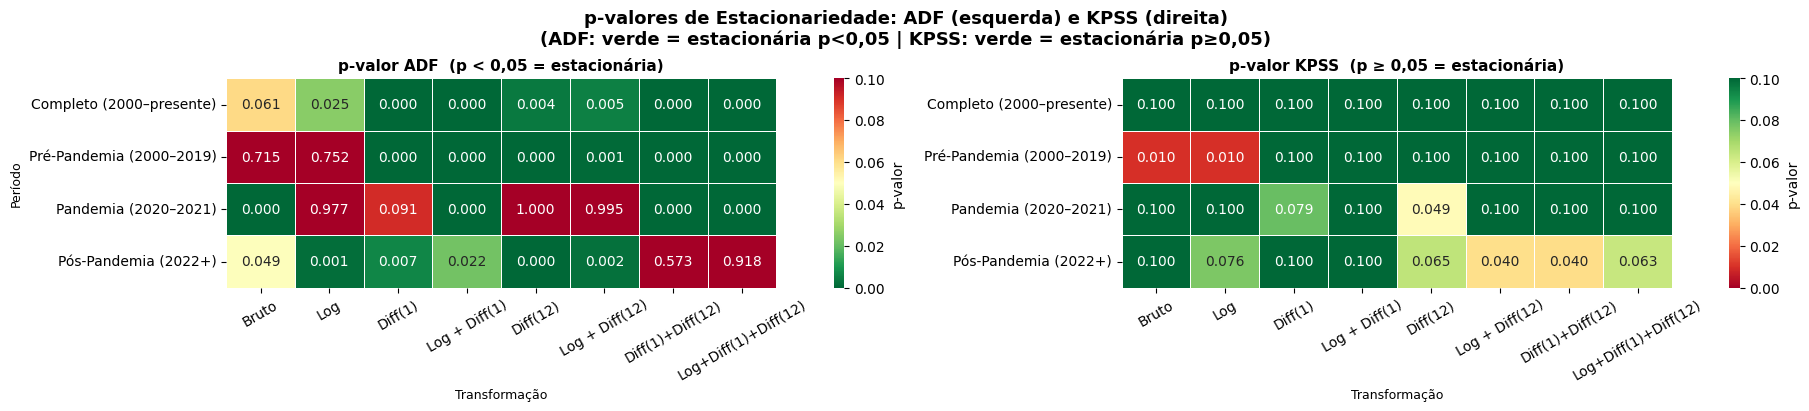

In [29]:
def run_adf(series, label):
    """ADF: H0 = raiz unitária (não estacionária). p < 0,05 → estacionária."""
    result = adfuller(series.dropna(), autolag='AIC')
    return {
        'label': label,
        'stat': result[0],
        'p': result[1],
        'lags': result[2],
        'stationary_adf': result[1] < 0.05,
    }


def run_kpss(series, label):
    """KPSS: H0 = estacionária. p < 0,05 → não estacionária."""
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        stat, p, lags, _ = kpss(series.dropna(), regression='c', nlags='auto')
    return {
        'label': label,
        'stat': stat,
        'p': p,
        'lags': lags,
        'stationary_kpss': p >= 0.05,
    }


def joint_verdict(adf_row, kpss_row):
    """
    ADF estacionária + KPSS estacionária → Estacionária
    ADF não estacionária + KPSS não estacionária → Não estacionária
    Divergência → Ambígua (diferenciar e retestar)
    """
    a, k = adf_row['stationary_adf'], kpss_row['stationary_kpss']
    if a and k:
        return 'Estacionária'
    if not a and not k:
        return 'Não estacionária'
    return 'Ambígua'


def test_series(series, label):
    a = run_adf(series, label)
    k = run_kpss(series, label)
    return a, k, joint_verdict(a, k)


stationarity_periods = [
    (
        'Completo (2000–presente)',
        monthly_df[monthly_df['period'] != 'Histórico (< 2000)']['arrival_count'],
    ),
    (
        'Pré-Pandemia (2000–2019)',
        monthly_df[monthly_df['period'] == 'Pré-Pandemia (2000–2019)']['arrival_count'],
    ),
    (
        'Pandemia (2020–2021)',
        monthly_df[monthly_df['period'] == 'Pandemia (2020–2021)']['arrival_count'],
    ),
    (
        'Pós-Pandemia (2022+)',
        monthly_df[monthly_df['period'] == 'Pós-Pandemia (2022+)']['arrival_count'],
    ),
]

transformations = [
    ('Bruto', lambda s: s),
    ('Log', lambda s: np.log(s.replace(0, np.nan))),
    ('Diff(1)', lambda s: s.diff(1)),
    ('Log + Diff(1)', lambda s: np.log(s.replace(0, np.nan)).diff(1)),
    ('Diff(12)', lambda s: s.diff(12)),
    ('Log + Diff(12)', lambda s: np.log(s.replace(0, np.nan)).diff(12)),
    ('Diff(1)+Diff(12)', lambda s: s.diff(1).diff(12)),
    ('Log+Diff(1)+Diff(12)', lambda s: np.log(s.replace(0, np.nan)).diff(1).diff(12)),
]

rows = []
for period_label, raw_series in stationarity_periods:
    for trans_label, fn in transformations:
        try:
            s = fn(raw_series).dropna()
            if len(s) < 8:
                continue
            adf_r, kpss_r, verdict = test_series(s, f'{period_label} | {trans_label}')
            rows.append({
                'Período': period_label,
                'Transformação': trans_label,
                'Estatística ADF': round(adf_r['stat'], 4),
                'p ADF': round(adf_r['p'], 4),
                'Lags ADF': adf_r['lags'],
                'ADF estacionária': '✓' if adf_r['stationary_adf'] else '✗',
                'Estatística KPSS': round(kpss_r['stat'], 4),
                'p KPSS': round(kpss_r['p'], 4),
                'KPSS estacionária': '✓' if kpss_r['stationary_kpss'] else '✗',
                'Veredicto conjunto': verdict,
            })
        except Exception as e:
            rows.append({
                'Período': period_label,
                'Transformação': trans_label,
                'Estatística ADF': None,
                'p ADF': None,
                'Lags ADF': None,
                'ADF estacionária': 'ERR',
                'Estatística KPSS': None,
                'p KPSS': None,
                'KPSS estacionária': 'ERR',
                'Veredicto conjunto': str(e),
            })

stat_df = pd.DataFrame(rows)

display_cols = [
    'Período',
    'Transformação',
    'p ADF',
    'ADF estacionária',
    'p KPSS',
    'KPSS estacionária',
    'Veredicto conjunto',
]

print('=' * 100)
print('RESULTADOS DOS TESTES DE ESTACIONARIEDADE — ADF + KPSS')
print('ADF  H0: raiz unitária (não estacionária) → rejeitar (p < 0,05) = estacionária')
print('KPSS H0: estacionária                     → rejeitar (p < 0,05) = não estacionária')
print('=' * 100)
print(stat_df[display_cols].to_string(index=False))

print()
print('=' * 70)
print('RECOMENDAÇÃO DE DIFERENCIAÇÃO PARA SARIMA')
print('=' * 70)

for period_label, raw_series in stationarity_periods:
    sub = stat_df[stat_df['Período'] == period_label]

    def verdict_for(trans):
        row = sub[sub['Transformação'] == trans]
        return row['Veredicto conjunto'].values[0] if len(row) else 'N/D'

    raw_v = verdict_for('Bruto')
    log_v = verdict_for('Log')
    d1_v = verdict_for('Diff(1)')
    log_d1_v = verdict_for('Log + Diff(1)')
    d12_v = verdict_for('Diff(12)')
    log_d12_v = verdict_for('Log + Diff(12)')

    if raw_v == 'Estacionária':
        d = 0
    elif d1_v == 'Estacionária':
        d = 1
    else:
        d = 2

    if raw_v == 'Estacionária' or log_v == 'Estacionária':
        D = 0
    elif d12_v == 'Estacionária' or log_d12_v == 'Estacionária':
        D = 1
    else:
        D = 1

    print(f'\n{period_label}')
    print(f'  Bruto        → {raw_v}')
    print(f'  Log          → {log_v}')
    print(f'  Diff(1)      → {d1_v}')
    print(f'  Log+Diff(1)  → {log_d1_v}')
    print(f'  Diff(12)     → {d12_v}')
    print(f'  Log+Diff(12) → {log_d12_v}')
    print(f'  Sugestão: d={d}, D={D}, s=12  →  SARIMA(p, {d}, q)(P, {D}, Q)[12]')

# Heatmap de p-valores
pivot_adf = stat_df.pivot_table(
    index='Período', columns='Transformação', values='p ADF', aggfunc='first'
)
pivot_kpss = stat_df.pivot_table(
    index='Período', columns='Transformação', values='p KPSS', aggfunc='first'
)

trans_order = [
    'Bruto', 'Log', 'Diff(1)', 'Log + Diff(1)',
    'Diff(12)', 'Log + Diff(12)', 'Diff(1)+Diff(12)', 'Log+Diff(1)+Diff(12)',
]
period_label_order = [
    'Completo (2000–presente)',
    'Pré-Pandemia (2000–2019)',
    'Pandemia (2020–2021)',
    'Pós-Pandemia (2022+)',
]

pivot_adf = pivot_adf.reindex(
    index=period_label_order, columns=[c for c in trans_order if c in pivot_adf.columns]
)
pivot_kpss = pivot_kpss.reindex(
    index=period_label_order,
    columns=[c for c in trans_order if c in pivot_kpss.columns],
)

fig, axes = plt.subplots(1, 2, figsize=(18, 4), constrained_layout=True)
fig.suptitle(
    'p-valores de Estacionariedade: ADF (esquerda) e KPSS (direita)\n'
    '(ADF: verde = estacionária p<0,05 | KPSS: verde = estacionária p≥0,05)',
    fontsize=13,
    fontweight='bold',
)

sns.heatmap(
    pivot_adf.astype(float),
    ax=axes[0],
    annot=True,
    fmt='.3f',
    cmap='RdYlGn_r',
    vmin=0,
    vmax=0.1,
    linewidths=0.4,
    cbar_kws={'label': 'p-valor'},
)
axes[0].set_title(
    'p-valor ADF  (p < 0,05 = estacionária)', fontsize=11, fontweight='bold'
)
axes[0].set_xlabel('Transformação', fontsize=9)
axes[0].set_ylabel('Período', fontsize=9)
axes[0].tick_params(axis='x', rotation=30)
axes[0].tick_params(axis='y', rotation=0)

sns.heatmap(
    pivot_kpss.astype(float),
    ax=axes[1],
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    vmin=0,
    vmax=0.1,
    linewidths=0.4,
    cbar_kws={'label': 'p-valor'},
)
axes[1].set_title(
    'p-valor KPSS  (p ≥ 0,05 = estacionária)', fontsize=11, fontweight='bold'
)
axes[1].set_xlabel('Transformação', fontsize=9)
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=30)
axes[1].tick_params(axis='y', rotation=0)

plt.show()

#### Autocorrelação

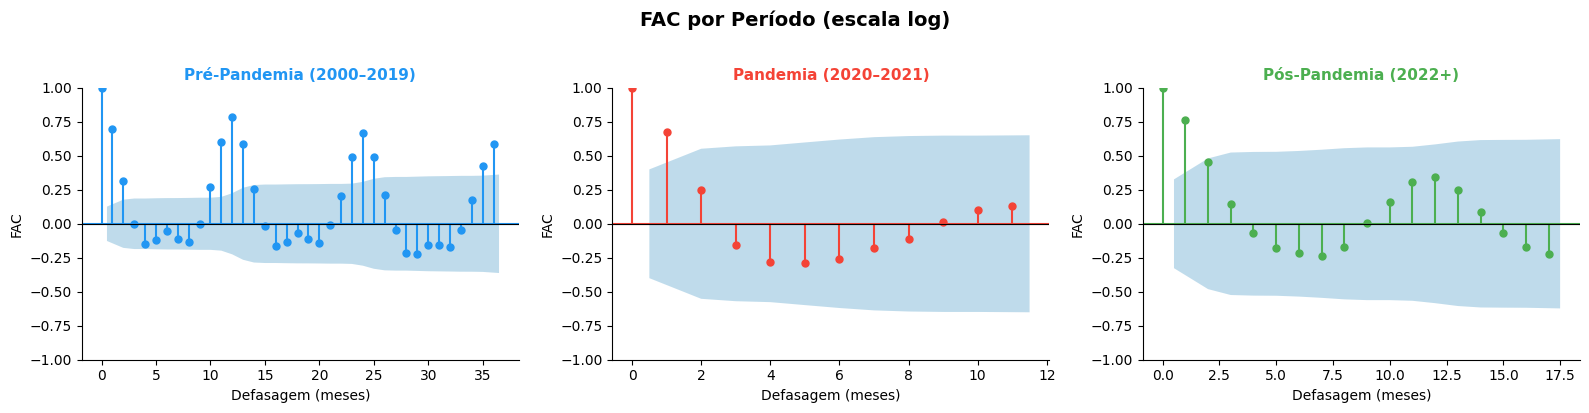

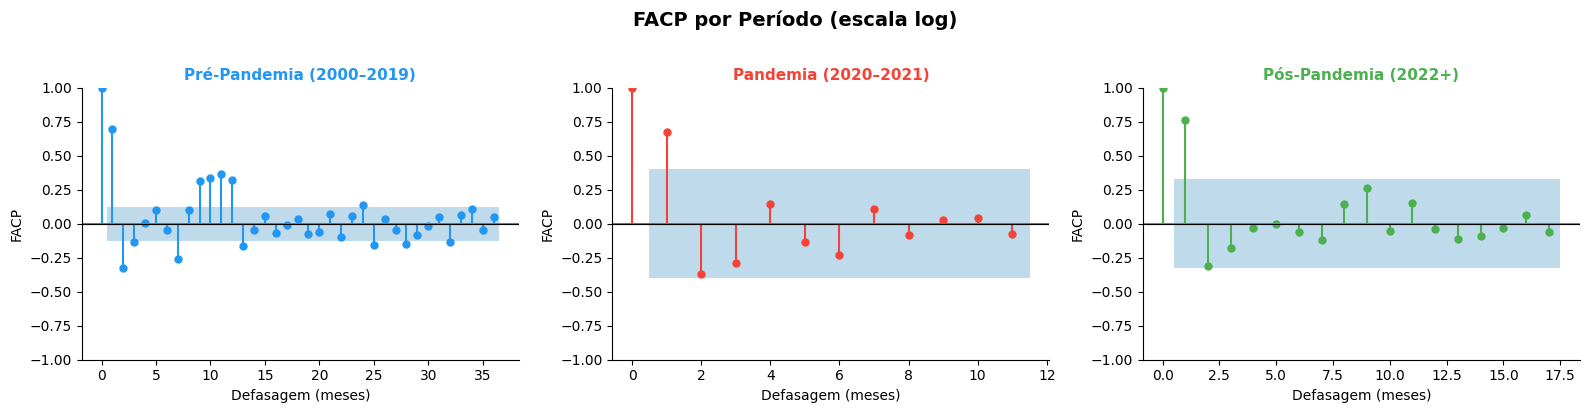

In [30]:
acf_periods = [
    'Pré-Pandemia (2000–2019)',
    'Pandemia (2020–2021)',
    'Pós-Pandemia (2022+)',
]

for plot_fn, fn_label in [(plot_acf, 'FAC'), (plot_pacf, 'FACP')]:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(
        f'{fn_label} por Período (escala log)', fontsize=14, fontweight='bold', y=1.02
    )

    for ax, period in zip(axes, acf_periods):
        series = np.log(monthly_df.loc[monthly_df['period'] == period, 'arrival_count'])
        lags = min(36, len(series) // 2 - 1)
        color = period_colors[period]

        plot_fn(series, lags=lags, ax=ax, color=color, vlines_kwargs={'colors': color})

        ax.set_title(period, fontsize=11, fontweight='bold', color=color)
        ax.set_xlabel('Defasagem (meses)', fontsize=10)
        ax.set_ylabel(fn_label, fontsize=10)
        ax.axhline(0, color='black', linewidth=0.8)
        sns.despine(ax=ax)

    plt.tight_layout()
    plt.show()

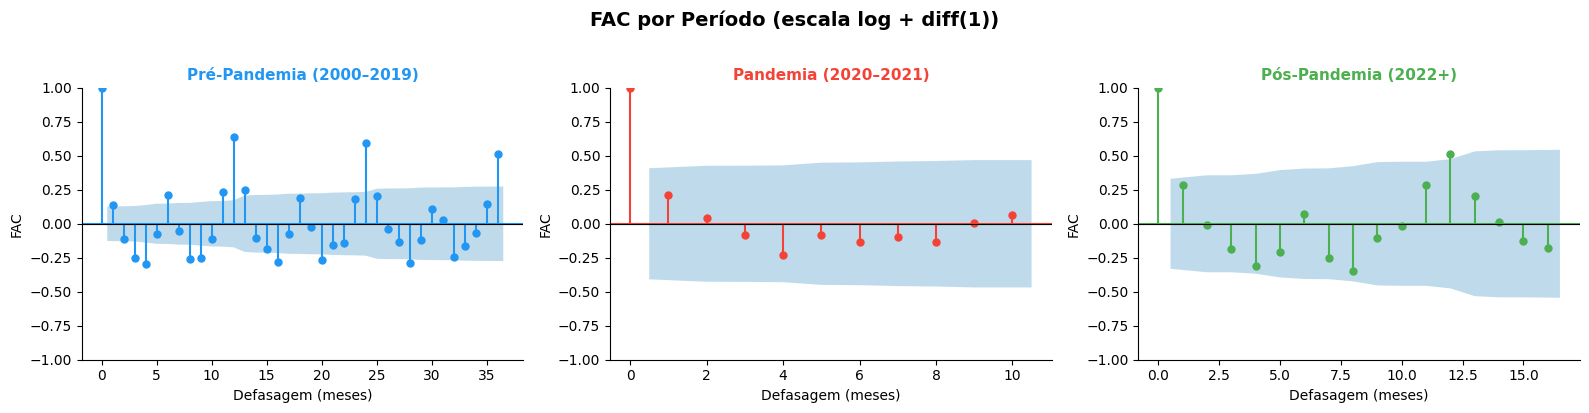

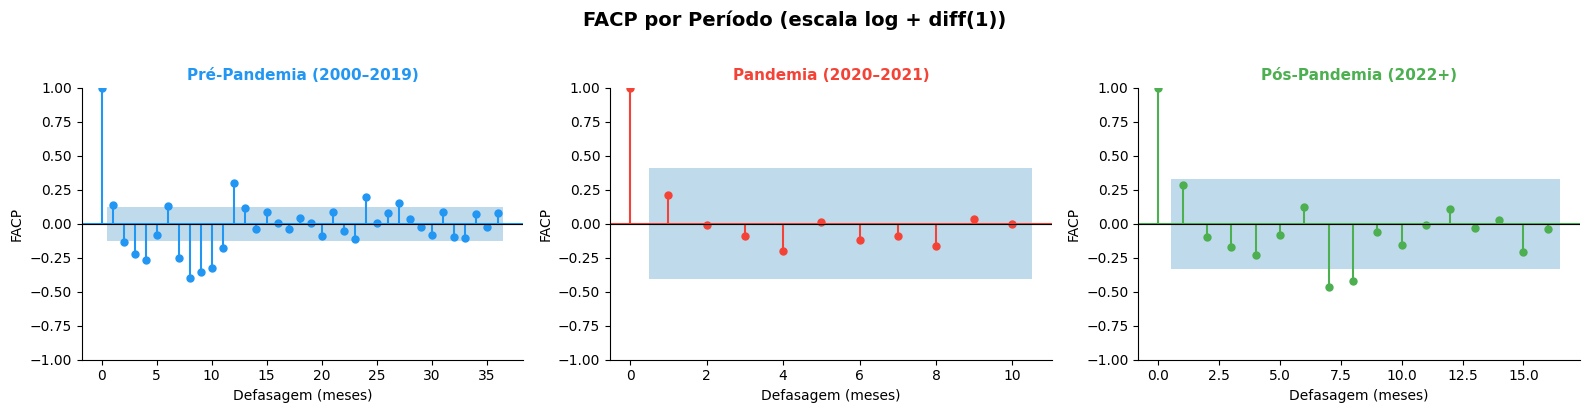

In [31]:
for plot_fn, fn_label in [(plot_acf, 'FAC'), (plot_pacf, 'FACP')]:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(
        f'{fn_label} por Período (escala log + diff(1))',
        fontsize=14,
        fontweight='bold',
        y=1.02,
    )

    for ax, period in zip(axes, acf_periods):
        series = (
            np
            .log(monthly_df.loc[monthly_df['period'] == period, 'arrival_count'])
            .diff(1)
            .dropna()
        )
        lags = min(36, len(series) // 2 - 1)
        color = period_colors[period]

        plot_fn(series, lags=lags, ax=ax, color=color, vlines_kwargs={'colors': color})

        ax.set_title(period, fontsize=11, fontweight='bold', color=color)
        ax.set_xlabel('Defasagem (meses)', fontsize=10)
        ax.set_ylabel(fn_label, fontsize=10)
        ax.axhline(0, color='black', linewidth=0.8)
        sns.despine(ax=ax)

    plt.tight_layout()
    plt.show()

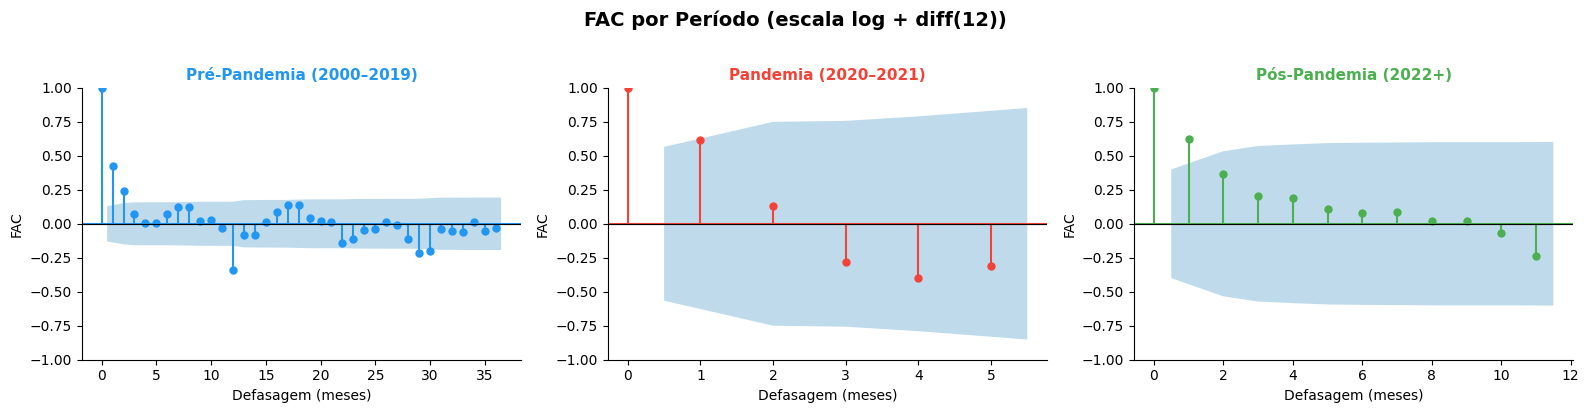

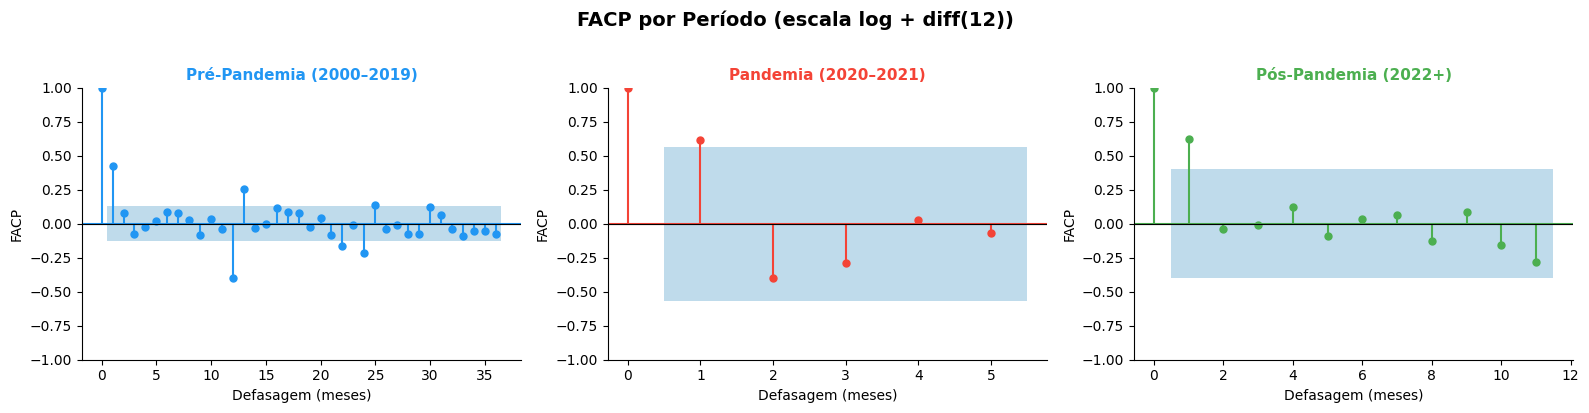

In [32]:
for plot_fn, fn_label in [(plot_acf, 'FAC'), (plot_pacf, 'FACP')]:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(
        f'{fn_label} por Período (escala log + diff(12))',
        fontsize=14,
        fontweight='bold',
        y=1.02,
    )

    for ax, period in zip(axes, acf_periods):
        series = (
            np
            .log(monthly_df.loc[monthly_df['period'] == period, 'arrival_count'])
            .diff(12)
            .dropna()
        )
        lags = min(36, len(series) // 2 - 1)
        color = period_colors[period]

        plot_fn(series, lags=lags, ax=ax, color=color, vlines_kwargs={'colors': color})

        ax.set_title(period, fontsize=11, fontweight='bold', color=color)
        ax.set_xlabel('Defasagem (meses)', fontsize=10)
        ax.set_ylabel(fn_label, fontsize=10)
        ax.axhline(0, color='black', linewidth=0.8)
        sns.despine(ax=ax)

    plt.tight_layout()
    plt.show()